# Flipkart Smartphone Price Analysis
**Objective:** Understand which features influence smartphone prices through data exploration, feature engineering, and visual analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sns.set_theme(style='white', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

### 1. Data Load and Explore

In [2]:
df = pd.read_excel('Processed_Flipdata.xlsx')
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='object')

In [3]:
# Fix column names
df.rename(columns={
    'Battery_': 'Battery',
    'Processor_': 'Processor',
    'Prize': 'Price'
}, inplace=True)
df_original_data = df.copy()

* The column names are not consistent. They have trailing underscores, and formatting is not uniform. It can cause trouble when we attempt to modify the data or use it to analyze it.
* Having standardized column names will make it easier to reference them and it will be reliable and can be used without any issues.

In [4]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


* The dataset contains detailed information on various mobile phones, including model name, color, memory, RAM, battery capacity, rear camera specifications, front camera specifications, presence of an AI lens, mobile height, processor, and price.

In [5]:
# Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

print("Shape:", df.shape)

Shape: (541, 11)


* The number of rows in this dataset is 541, and the number of columns is 12.
* There is a column in dataset named "Unnamed: 0" that doesn't include any meaningful data and is an index column, so it is dropped to keep the dataset clean and relevant.

In [6]:
df.info()
print('Null Values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery        541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor      541 non-null    object 
 10  Price          541 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 46.6+ KB
Null Values:
Model            0
Colour           0
Memory           0
RAM              0
Battery          0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor        0
Price            0
dtype: int64


* The dataset does not contain any missing values across all columns.
* This indicates that all records are complete, and can be analysed without handling missing data
* The data types are mixed, with some columns as numbers and others as text, especially in columns like processor and camera.

In [7]:
df.describe().round(2)

,Memory,RAM,Battery,AI Lens,Mobile Height,Price
count,541.00,541.00,541.00,541.00,541.00,541.00
mean,110.55,5.40,4871.59,0.06,16.43,16228.38
std,60.60,1.98,780.15,0.24,2.52,10793.59
min,16.00,2.00,800.00,0.00,4.50,920.00
25%,64.00,4.00,5000.00,0.00,16.51,9290.00
50%,128.00,6.00,5000.00,0.00,16.71,13499.00
75%,128.00,8.00,5000.00,0.00,16.94,19280.00
max,256.00,8.00,7000.00,1.00,41.94,80999.00


* There are 541 devices included in the dataset.
* Price varies a lot, from very cheap to very expensive phones, which shows the dataset includes budget, mid-range, and premium devices.
* RAM varies between 2GB and 8GB, and average RAM value is 5.4GB with median equal to 6GB.
* The values for battery are extremely concentrated
* As for memory capacity, its median is 128GB, and 75% of data falls at the same value.
* Mobile height varies significantly from 4.5 cm to 41.94 cm, which means that there are some extreme devices.
* AI Lens has a mean equal to 0.06, which indicates that it is a rare feature available. 

In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates}")
df[df.duplicated(keep=False)]

Duplicates: 10


,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
23,vivo T2x 5G,Marine Blue,128,6,5000,50MP,8MP,0,16.71,Dimensity 6020,13999
27,vivo T2x 5G,Marine Blue,128,6,5000,50MP,8MP,0,16.71,Dimensity 6020,13999
46,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,7999
48,MOTOROLA e32,Arctic Blue,64,4,5000,50MP,8MP,0,16.51,Mediatek Helio G37,7999
90,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",13490
91,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",13490
130,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",14490
132,SAMSUNG Galaxy F14 5G,OMG Black,128,6,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",14490
246,redmi min,M3),16,4,1000,0MP,0MP,0,4.57,Spreadtrum,920
247,redmi min,M3),16,4,1000,0MP,0MP,0,4.57,Spreadtrum,920


In [9]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates: {df.duplicated().sum()}")
print(f"shape: {df.shape}")

Duplicates: 0
shape: (531, 11)


* The dataset had 10 duplicate rows, where all feature values, such as model name, color, memory, RAM, battery capacity, camera specifications, mobile height, processor, and price, all were the same. 
* These duplicates do not add any new information and only repeat the same device entries, which can affect the analysis.
* Removing duplicates ensures each device is counted only once, improving the reliability of the dataset and making the analysis more accurate.

---

### 2. Feature Engineering
* New features are created from raw columns to make the data more useful for analysis.

#### A. Camera Score
* The dataset has three camera-related features: `Rear Camera`, `Front Camera` are in text format, and `AI Lens` is in binary format.

In [10]:
# Extract numeric MP values from text strings
df['rear_camera_mp']  = df['Rear Camera'].str.extract(r'(\d+)').astype('Int64')
df['front_camera_mp'] = df['Front Camera'].str.extract(r'(\d+)').astype('Int64')

print("Unique front MP values:", sorted(df['front_camera_mp'].unique()))
print("Unique rear MP values: ", sorted(df['rear_camera_mp'].unique()))

Unique front MP values: [np.int64(0), np.int64(2), np.int64(5), np.int64(8), np.int64(10), np.int64(12), np.int64(13), np.int64(16), np.int64(20), np.int64(32), np.int64(44), np.int64(50), np.int64(60)]
Unique rear MP values:  [np.int64(0), np.int64(2), np.int64(5), np.int64(8), np.int64(12), np.int64(13), np.int64(16), np.int64(32), np.int64(40), np.int64(48), np.int64(50), np.int64(64), np.int64(108), np.int64(200)]


In [11]:
# Drop original text columns
df.drop(columns=['Rear Camera', 'Front Camera'], inplace=True)
print("Dropped original camera text columns.")
print("Remaining columns:", df.columns.tolist())

Dropped original camera text columns.
Remaining columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery', 'AI Lens', 'Mobile Height', 'Processor', 'Price', 'rear_camera_mp', 'front_camera_mp']


* The camera values are originally stored in text format, so the numeric values are extracted and converted into numbers for proper analysis.
* The original text columns were then removed to keep the dataset clean.
* After conversion, the unique values are checked to understand the range from both cameras.
* Front camera values range from 0 to 60 MP, and rear camera values range from 0 to 200 MP.
* This confirms that the data has realistic variations, including some devices with no camera (0 MP) and some high-end models with very high camera resolution.

In [12]:
# Check min and max for front and rear cameras
print("Front min:", df['front_camera_mp'].min())
print("Front max:", df['front_camera_mp'].max())
print("Rear min:", df['rear_camera_mp'].min())
print("Rear max:", df['rear_camera_mp'].max())

Front min: 0
Front max: 60
Rear min: 0
Rear max: 200


* Front camera ranges from 0 to 60 MP, while rear camera ranges from 0 to 200 MP.
* Both features include zero values, which shows that some devices do not have a camera.
* This confirms that the data has realistic variations, including some devices with no camera (0 MP) and some high-end models with very high camera resolution.
* The large difference in ranges shows that rear camera values are much higher than front camera values, so normalization is needed before combining them.

In [13]:
# Check phones with 0MP
print(df[df['front_camera_mp'] == 0][['Model', 'front_camera_mp', 'rear_camera_mp', 'Price']])

              Model  front_camera_mp  rear_camera_mp  Price
95   Micromax IN 2C                0               0   1449
105      micromax 2                0               2   1849
113        micromax                0               0   1422
115      micromax 1                0               0   1299
129      Micromax 3                0               2   2615
148      micromax 3                0               2   2490
151      micromax 2                0               0   1299
152      micromax 3                0               2   2499
177        micromax                0               0   1375
178       micromax1                0               0   1599
189      micromax 2                0               2   2499
240       redmi max                0               2   3549
241      redmi mono                0               0   1699
242       redmi min                0               0    920
245        micromax                0               0   1199


* Devices with 0 MP front camera mostly belong to very low-priced models, mainly from brands like Micromax and some Redmi entries.
* Many of these devices also have 0 MP rear cameras or very low rear camera values, which shows they are basic or keypad-type devices.
* Prices for these devices are very low, mostly between ₹920 and ₹3,549, confirming that the absence of a camera is linked with entry-level devices.
* This also explains why the minimum camera score is zero.
* The presence of these values helps maintain realistic distribution and improves the interpretability of the feature.

In [14]:
# Camera availability for devices
df['has_front_camera'] = (df['front_camera_mp'] > 0).astype(int)
df['has_rear_camera']  = (df['rear_camera_mp'] > 0).astype(int)

df.groupby(['has_front_camera','has_rear_camera'])['Price'].agg(['count','mean'])

count          mean
has_front_camera has_rear_camera                     
0                0                    9   1362.333333
                 1                    6   2583.500000
1                1                  516  16725.978682

* Devices are grouped based on whether they have front and rear cameras.
* Devices with no front and no rear camera have the lowest average price (₹1,362), showing they are basic devices.
* Devices with only a rear camera have a slightly higher average price (₹2,583), but still remain in the low-price range.
* Most devices, around 516, have both front and rear cameras, and their average price is higher (₹16,726).
* The presence of a front camera appears to be a key differentiator, as price increases sharply only when both cameras are available.

In [15]:
# Check correlation between cameras and AI Lense with Price
print("Front Camera MP vs Price:")
print(df[['front_camera_mp', 'Price']].corr().round(4), "\n")

print("Rear Camera MP vs Price:")
print(df[['rear_camera_mp', 'Price']].corr().round(4), "\n")

print("AI Lens vs Price:")
print(df[['AI Lens', 'Price']].corr().round(4), "\n")

print("AI Lens average price by group:")
print(df.groupby('AI Lens')['Price'].mean().round(0))

Front Camera MP vs Price:
                 front_camera_mp  Price
front_camera_mp            1.000  0.529
Price                      0.529  1.000 

Rear Camera MP vs Price:
                rear_camera_mp   Price
rear_camera_mp          1.0000  0.4068
Price                   0.4068  1.0000 

AI Lens vs Price:
         AI Lens   Price
AI Lens   1.0000 -0.1563
Price    -0.1563  1.0000 

AI Lens average price by group:
AI Lens
0    16749.0
1     9828.0
Name: Price, dtype: float64


* Front camera shows a moderate positive relationship with price (~ 0.53), which means phones with better front cameras generally cost more.
* Rear camera also shows a positive relationship (~ 0.41), but it is slightly weaker than the front camera.
* AI Lens shows a weak negative relationship with price (~ -0.16), which means it does not increase price and is more common in lower-priced devices.
* Comparing with the average price, phones without AI Lens have a higher average price (₹16,749) than phones with AI Lens (₹9,828).
* This indicates that AI Lens is more commonly used in budget smartphones and does not represent a premium camera feature in this dataset.

In [16]:
# Check correlation between front camera with rear camera
print("Front camera vs Rear camera correlation:")
print(df[['front_camera_mp', 'rear_camera_mp']].corr().round(4))
shared = df['front_camera_mp'].corr(df['rear_camera_mp'])**2
print(f"\nShared variance: {shared*100:.1f}%")

Front camera vs Rear camera correlation:
                 front_camera_mp  rear_camera_mp
front_camera_mp           1.0000          0.5022
rear_camera_mp            0.5022          1.0000

Shared variance: 25.2%


* Front camera and rear camera show a moderate positive correlation (~ 0.50), which means devices with higher rear camera values also tend to have higher front camera values.
* Front and rear cameras share ~25% variance. This means that around one-fourth of the variation in one camera is explained by the other and 75% of their information is independent.
* This shows that both cameras are related, but they do not move together strongly and still vary independently in many devices.

In [17]:
# Normalize each feature to 0–1 (to fixes scale difference)
df['front_norm'] = (df['front_camera_mp'] - df['front_camera_mp'].min()) / \
                   (df['front_camera_mp'].max() - df['front_camera_mp'].min())

df['rear_norm']  = (df['rear_camera_mp'] - df['rear_camera_mp'].min()) / \
                   (df['rear_camera_mp'].max() - df['rear_camera_mp'].min())

print("Front norm — min:", df['front_norm'].min(), "max:", df['front_norm'].max())
print("Rear norm  — min:", df['rear_norm'].min(),  "max:", df['rear_norm'].max())

Front norm — min: 0.0 max: 1.0
Rear norm  — min: 0.0 max: 1.0


* Front and rear camera values are brought to the same 0 to 1 scale so that a 108MP rear camera and a 32MP front camera are fairly compared without one dominating the other just because of its bigger number.
* After scaling, both features stay between 0.0 and 1.0, which makes them comparable and suitable for combined use.

In [18]:
# Count cameras present per device
df['camera_count'] = (
    (df['front_camera_mp'] > 0).astype(int) +
    (df['rear_camera_mp']  > 0).astype(int)
)

print("Camera count distribution:")
print(df['camera_count'].value_counts().sort_index())
print("\nAverage price by camera count:")
print(df.groupby('camera_count')['Price'].mean().round(0))

Camera count distribution:
camera_count
0      9
1      6
2    516
Name: count, dtype: int64

Average price by camera count:
camera_count
0     1362.0
1     2584.0
2    16726.0
Name: Price, dtype: float64


* Camera availability is converted into a count feature.
* Devices are grouped into three categories: no camera (0), one camera (1), and both cameras (2).
* Missing cameras are treated as feature absence, not as zero performance.

In [19]:
# Build camera score
df['camera_score'] = (
    (df['front_norm'] * (df['front_camera_mp'] > 0).astype(int)) +
    (df['rear_norm']  * (df['rear_camera_mp']  > 0).astype(int))
) / df['camera_count'].replace(0, np.nan)

df['camera_score'] = df['camera_score'].fillna(0) * 10

print("Camera Score Stats:")
print(df['camera_score'].describe().round(3))

Camera Score Stats:
count    531.0
mean      2.16
std      1.337
min        0.0
25%      1.029
50%      1.917
75%      2.583
max       10.0
Name: camera_score, dtype: Float64


* A camera score is created by combining front and rear camera values after normalization, so both cameras contribute equally without scale issues. 
* The score is adjusted using camera count, which ensures that devices with only one camera are evaluated correctly and missing cameras are treated as feature absence, not zero performance.
* The camera score ranges from 0 to 10, with an average around 2.16, showing most devices have lower to mid-level combined camera performance.
* When compared with price, camera score shows a correlation of ~ 0.54, which is slightly higher than the front camera (0.53) and clearly higher than the rear camera (0.41). 
* This shows that combining both cameras into a single score gives a better representation of camera quality in relation to price.
* AI Lens is excluded from the camera score because it shows a negative correlation with price and does not contribute to better camera performance representation.

In [20]:
# Create camera tier for group analysis
df['camera_tier'] = pd.qcut(df['camera_score'], q=3, labels=['Low', 'Mid', 'High'])

print("Average price by camera tier:")
print(df.groupby('camera_tier', observed=True)['Price'].mean().round(0))

Average price by camera tier:
camera_tier
Low     10040.0
Mid     16651.0
High    25936.0
Name: Price, dtype: float64


* Devices are grouped into Low, Mid, and High camera tiers, and average price increases clearly across these groups, with Low at ₹10,040, Mid at ₹16,651, and High at ₹25,936, confirms camera score works well as a price differentiator.
* It becomes easier to compare price differences across camera quality
* This shows that better camera quality is associated with higher-priced devices.

#### B. Brand Extraction & Standardisation
* Brand is extracted from the Model column by taking the first word after text normalisation.

In [21]:
print(df['Model'].sample(20, random_state=42))
print("\nTotal unique models:", df['Model'].nunique())

517              vivo Y100 5G
6             Infinix HOT 30i
322           Google Pixel 7a
416               realme C30s
497        Infinix Hot 12 Pro
185           realme C33 2023
75                    POCO M5
104    realme Narzo 30 Pro 5G
180            realme 9 5G SE
403               realme C30s
530                  OPPO A77
457            Nokia C01 Plus
10                   REDMI 10
238                POCO F5 5G
72                POCO M4 Pro
70                 POCO X5 5G
341            Tecno Spark 9T
2                MOTOROLA G32
361                  itel A60
518        SAMSUNG Galaxy A23
Name: Model, dtype: object

Total unique models: 187


* The dataset contains 187 unique models, which shows that many devices are repeated and the dataset is not made of completely unique entries.
* Sample values show a mix of different brands and models, including budget and premium devices, which confirms variety in the dataset.

In [22]:
print(df['Model'].unique())

['Infinix SMART 7' 'MOTOROLA G32' 'POCO C50' 'Infinix HOT 30i' 'REDMI 10'
 'SAMSUNG Galaxy F13' 'SAMSUNG Galaxy F04' 'POCO C51' 'MOTOROLA e13'
 'vivo T2x 5G' 'Infinix Smart 7 HD' 'REDMI A1+' 'POCO C55' 'MOTOROLA g13'
 'POCO M4 5G' 'MOTOROLA e32' 'vivo T2 5G' 'MOTOROLA G62 5G' 'POCO M5'
 'realme C33 2023' 'SAMSUNG Galaxy F14 5G' 'MOTOROLA g73 5G' 'realme C30'
 'POCO X5 5G' 'POCO M4 Pro' 'REDMI 11 Prime' 'realme C55'
 'realme 10 Pro 5G' 'Micromax IN 2C' 'POCO M4 Pro 5G'
 'realme Narzo 30 Pro 5G' 'micromax 2' 'Infinix Note 12 Pro 5G'
 'SAMSUNG Galaxy F23 5G' 'micromax' 'MOTOROLA Edge 40' 'micromax 1'
 'realme Narzo 30' 'Infinix NOTE 12i' 'realme 10' 'realme 8i' 'Micromax 3'
 'Google Pixel 6a' 'Infinix HOT 20 5G' 'realme GT 2' 'REDMI Note 12'
 'REDMI Note 12 5G' 'micromax 3' 'SAMSUNG Galaxy M04' 'REDMI K50i 5G'
 'MOTOROLA e40' 'REDMI 9 Activ' 'MOTOROLA g42' 'realme C25s'
 'POCO X5 Pro 5G' 'POCO M3 Pro 5G' 'Infinix Smart 6 HD'
 'Infinix Hot 20 5G' 'realme C31' 'micromax1' 'OPPO A17' 'realme

* Model names have many different formats, like different spacing, versions, and naming styles.
* Because of this, the model column is useful for identification but not useful for direct analysis without further processing.

In [23]:
df['Model_clean'] = df['Model'].str.lower().str.strip()
print(df[['Model', 'Model_clean']].head(10))

             Model      Model_clean
0  Infinix SMART 7  infinix smart 7
1  Infinix SMART 7  infinix smart 7
2     MOTOROLA G32     motorola g32
3         POCO C50         poco c50
4  Infinix HOT 30i  infinix hot 30i
5  Infinix HOT 30i  infinix hot 30i
6  Infinix HOT 30i  infinix hot 30i
7  Infinix HOT 30i  infinix hot 30i
8  Infinix HOT 30i  infinix hot 30i
9  Infinix HOT 30i  infinix hot 30i


* Model names are converted to lowercase, and extra spaces are removed to create a clean and consistent format.
* This helps avoid mismatches caused by different text styles and ensures the same model is treated as one value during analysis.

In [24]:
# Extract brand as first word of cleaned model name
df['brand'] = df['Model_clean'].str.split().str[0]

print("Brand extracted. Sample:")
print(df[['Model', 'Model_clean', 'brand']].head(10))

Brand extracted. Sample:
             Model      Model_clean     brand
0  Infinix SMART 7  infinix smart 7   infinix
1  Infinix SMART 7  infinix smart 7   infinix
2     MOTOROLA G32     motorola g32  motorola
3         POCO C50         poco c50      poco
4  Infinix HOT 30i  infinix hot 30i   infinix
5  Infinix HOT 30i  infinix hot 30i   infinix
6  Infinix HOT 30i  infinix hot 30i   infinix
7  Infinix HOT 30i  infinix hot 30i   infinix
8  Infinix HOT 30i  infinix hot 30i   infinix
9  Infinix HOT 30i  infinix hot 30i   infinix


In [25]:
# Check repeated model names
dup_count = df['Model_clean'].duplicated().sum()
print(f"Duplicate model names: {dup_count}")

Duplicate model names: 350


In [26]:
# Duplicate model entries 
print("Sample of repeated model entries (different colours/variants):")
print(df[df['Model_clean'].duplicated(keep=False)]
      .sort_values('Model_clean')
      [['Model', 'Colour', 'Memory', 'RAM', 'Price']]
      .head(12))

Sample of repeated model entries (different colours/variants):
                    Model      Colour  Memory  RAM  Price
515  APPLE iPhone 14 Plus   Starlight     128    4  80999
483  APPLE iPhone 14 Plus    Midnight     128    6  80999
510  APPLE iPhone 14 Plus      Purple     128    3  80999
132       Google Pixel 6a    Charcoal     128    6  28999
131       Google Pixel 6a       Chalk     128    6  28999
324       Google Pixel 6a       chalk     128    8  30999
410        Google Pixel 7    Obsidian     128    8  55999
418        Google Pixel 7  Lemongrass     128    8  55999
409        Google Pixel 7        Snow     128    8  55999
303       Google Pixel 7a         Sea     128    8  43999
304       Google Pixel 7a    Charcoal     128    8  43999
322       Google Pixel 7a        Snow     128    8  43999


* Brand is extracted from the cleaned model name by taking the first word, which helps create a separate feature for brand-level analysis.
* There are 350 duplicate model entries, which show that many models repeat multiple times in the dataset.
* Duplicate rows show the same model appearing with different variants like colour or minor specification changes, but the core model name remains the same.
* This confirms that the dataset includes multiple entries for the same model rather than fully unique devices.

In [27]:
print("Top brand counts:\n")
print(df['brand'].value_counts().head(20))

print("\nUnique brands:", df['brand'].nunique())

Top brand counts:

brand
realme       97
redmi        74
infinix      65
vivo         60
poco         58
samsung      53
motorola     45
tecno        16
oppo         16
micromax     13
google        9
oneplus       5
apple         5
itel          3
nokia         3
nothing       2
i             2
iqoo          2
lava          2
micromax1     1
Name: count, dtype: int64

Unique brands: 20


In [28]:
# Fix 1: 'I Kall' extracted as 'i' — correct to 'ikall'
print("Before fix:")
print("  'i' count    :", (df['brand'] == 'i').sum())
print("  'ikall' count:", (df['brand'] == 'ikall').sum())

df.loc[df['Model_clean'].str.contains('i kall', case=False), 'brand'] = 'ikall'

print("\nAfter fix:")
print("  'i' count    :", (df['brand'] == 'i').sum())
print("  'ikall' count:", (df['brand'] == 'ikall').sum())

Before fix:
  'i' count    : 2
  'ikall' count: 0

After fix:
  'i' count    : 0
  'ikall' count: 2


In [29]:
# Fix 2: 'micromax1' is correct to 'micromax'
print("Before fix:")
print("  'micromax' count :", (df['brand'] == 'micromax').sum())
print("  'micromax1' count:", (df['brand'] == 'micromax1').sum())

df['brand'] = df['brand'].replace({'micromax1': 'micromax'})

print("\nAfter fix:")
print("  'micromax' count :", (df['brand'] == 'micromax').sum())
print("  'micromax1' count:", (df['brand'] == 'micromax1').sum())

Before fix:
  'micromax' count : 13
  'micromax1' count: 1

After fix:
  'micromax' count : 14
  'micromax1' count: 0


* Brand is extracted from the model name to create a clean and consistent feature for analysis.
* Text is converted to lowercase and spaces are removed to avoid mismatch in brand names.
* Initial brand counts show some inconsistencies, such as “ikall” being extracted as “i” and “micromax” appearing as “micromax1”.
* These issues are corrected to standardize brand names.
* After fixing it, brand values become more accurate and consistent, ensuring correct grouping and reliable analysis based on brand.

In [30]:
# Merge sub-brands into parent brands
brand_mapping = {
    'redmi': 'xiaomi',
    'poco':  'xiaomi',
    'mi':    'xiaomi',
    'iqoo':  'vivo'
}
df['brand'] = df['brand'].replace(brand_mapping)

print("After merging sub-brands:")
print(df['brand'].value_counts())
print("\nUnique brands:", df['brand'].nunique())

After merging sub-brands:
brand
xiaomi      132
realme       97
infinix      65
vivo         62
samsung      53
motorola     45
tecno        16
oppo         16
micromax     14
google        9
oneplus       5
apple         5
itel          3
nokia         3
nothing       2
ikall         2
lava          2
Name: count, dtype: int64

Unique brands: 17


* Sub-brands like Redmi, POCO, and Mi are merged into Xiaomi, and iQOO is merged into Vivo to represent parent brands correctly.
* This avoids splitting the same company into multiple categories and gives a more accurate view of brand presence. After merging, the number of unique brands reduces to 17.

In [31]:
# Group rare brands (count <= 3) into 'other'
total = len(df)
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts <= 3]

print(f"Rare brands: {rare_brands.sum()} rows ({rare_brands.sum()/total*100:.1f}%)")
print(rare_brands)

Rare brands: 12 rows (2.3%)
brand
itel       3
nokia      3
nothing    2
ikall      2
lava       2
Name: count, dtype: int64


*  Brands with very low presence (count ≤ 3) are identified as rare.
*  These include brands like Itel, Nokia, Nothing, iKall, and Lava. 
* They together make up only 12 rows (2.3%), which is a very small portion of the dataset.

In [32]:
brand_counts = df['brand'].value_counts()
rare_brands  = brand_counts[brand_counts <= 3]

brand_before = df['brand'].value_counts().copy()

df['brand'] = df['brand'].replace(rare_brands.index, 'other')

brand_after = df['brand'].value_counts().copy()

print("Unique brands after grouping:", df['brand'].nunique())
print("\nFinal brand counts:")
print(df['brand'].value_counts())

Unique brands after grouping: 13

Final brand counts:
brand
xiaomi      132
realme       97
infinix      65
vivo         62
samsung      53
motorola     45
oppo         16
tecno        16
micromax     14
other        12
google        9
oneplus       5
apple         5
Name: count, dtype: int64


In [33]:
# Before vs After comparison
comparison = pd.DataFrame({
    'Before': brand_before,
    'After':  brand_after
}).fillna(0).astype(int)

print("Brand grouping")
print(comparison)

Brand grouping
          Before  After
brand                  
apple          5      5
google         9      9
ikall          2      0
infinix       65     65
itel           3      0
lava           2      0
micromax      14     14
motorola      45     45
nokia          3      0
nothing        2      0
oneplus        5      5
oppo          16     16
other          0     12
realme        97     97
samsung       53     53
tecno         16     16
vivo          62     62
xiaomi       132    132


* Brands with very small counts are grouped into one category called “other”.
* After grouping, the total number of brands becomes 13, which makes the dataset simpler and easier to understand.
* Major brands like Xiaomi, Realme, Infinix, Vivo, and Samsung remain unchanged, while only small brands move into “other”.

In [34]:
print("Average price by brand:")
print(df.groupby('brand')['Price'].mean().sort_values(ascending=False).round(0))

Average price by brand:
brand
apple       67639.0
google      43221.0
oneplus     29977.0
samsung     21031.0
vivo        20205.0
motorola    16797.0
oppo        16120.0
xiaomi      15871.0
realme      13544.0
other       10822.0
infinix     10621.0
tecno        8599.0
micromax     2399.0
Name: Price, dtype: float64


* Brand has a strong influence on price.
* Average price is calculated for each brand to understand how pricing differs across brands.
* Apple has the highest average price (₹67,639), followed by Google (₹43,221) and OnePlus (₹29,977), which shows these brands focus on premium devices.
* Brands like Samsung, Vivo, Motorola, Oppo, Xiaomi, and Realme fall in the mid-range, with prices spread across different segments.
* Brands like Infinix, Tecno, Micromax, and “other” have much lower average prices, which shows they mainly target budget devices.

In [35]:
# Average price per brand per RAM tier
# To check whether RAM affects price differently across brands
print("Average price by Brand + RAM:")
print(df.groupby(['brand', 'RAM'])['Price']
      .mean()
      .round(0)
      .unstack()
      .fillna('-'))

Average price by Brand + RAM:
RAM             2        3        4        6        8
brand                                                
apple           -  80999.0  80999.0  80999.0  47599.0
google          -        -        -  28999.0  47285.0
infinix    6499.0        -   9130.0  12221.0  14721.0
micromax        -   3743.0   2121.0   1449.0   1482.0
motorola   6799.0        -  12395.0  19499.0  22932.0
oneplus         -        -        -  29790.0  30024.0
oppo            -   9572.0  13093.0        -  22024.0
other      6014.0   7999.0   8596.0        -  29999.0
realme    10592.0   8496.0  11315.0  16666.0  19525.0
samsung         -   9999.0  12191.0  18226.0  36732.0
tecno           -   7415.0   8651.0  13999.0        -
vivo            -  10679.0  17913.0  19286.0  23454.0
xiaomi     9154.0   6983.0  12367.0  16171.0  22841.0


* Price is compared across brands for each RAM level to understand how RAM affects pricing within different brands.
* Price increases as RAM increases, but the increase is not the same for every brand.
* Premium brands like Apple and Google show much higher prices even at similar RAM levels, while brands like Infinix, Micromax, and others stay much lower.
* This shows that price does not depend only on RAM; brand value also plays a big role.
* This helps in understanding how different brands position their products even with similar specifications.

In [36]:
# Average price per brand per Memory tier
print("Average price by Brand + Memory:")
print(df.groupby(['brand', 'Memory'])['Price']
      .mean()
      .round(0)
      .unstack()
      .fillna('-'))

Average price by Brand + Memory:
Memory       16       32       64       128      256
brand                                               
apple          -        -  47599.0  80999.0        -
google         -        -        -  43221.0        -
infinix        -   6299.0   9004.0  13562.0  17599.0
micromax       -   3494.0   1844.0   1834.0   1699.0
motorola       -        -   9784.0  18094.0  37999.0
oneplus        -        -        -  27741.0  38920.0
oppo           -        -  10969.0  21270.0        -
other     5799.0   6381.0   8596.0  29999.0        -
realme         -   7331.0  11287.0  16547.0  22382.0
samsung        -        -  11115.0  20408.0  45599.0
tecno          -   7021.0   8682.0  13999.0        -
vivo           -  10455.0  11341.0  20245.0  32148.0
xiaomi    2792.0   6662.0  11241.0  16595.0  27624.0


* Price is compared across brands for each storage level to see how memory affects pricing.
* Price generally increases as storage increases, but the pattern changes across brands.
* Some brands charge much higher prices even at the same storage level, while others remain affordable.
* For example, premium brands stay expensive, while budget brands stay low even at higher storage.
* This shows that storage impacts price, but brand influence is still very strong.
* This helps in understanding real pricing differences across brands for similar storage options.

In [37]:
# Same specs (4GB RAM + 64GB), price difference by brand only
print("Phones with 4GB RAM + 64GB Storage — avg price by brand:")
print(df[(df['RAM'] == 4) & (df['Memory'] == 64)]
      .groupby('brand')['Price']
      .mean()
      .sort_values()
      .round(0))

Phones with 4GB RAM + 64GB Storage — avg price by brand:
brand
micromax     1844.0
other        8596.0
tecno        8651.0
infinix      9130.0
xiaomi      10220.0
motorola    10344.0
realme      11218.0
samsung     11239.0
vivo        11999.0
oppo        12367.0
Name: Price, dtype: float64


* Phones with the same specs (4GB RAM and 64GB storage) are compared across brands to see price difference based only on brand.
* Even with the same specs, price changes a lot across brands.
* Micromax has the lowest price (₹1,844), while brands like Oppo, Vivo, Samsung, and Realme are much higher.
* This shows that brand value affects price strongly, even when hardware is the same.

In [38]:
# Same specs (8GB RAM + 128GB), price difference by brand only
print("Phones with 8GB RAM + 128GB Storage — avg price by brand:")
print(df[(df['RAM'] == 8) & (df['Memory'] == 128)]
      .groupby('brand')['Price']
      .mean()
      .sort_values()
      .round(0))

Phones with 8GB RAM + 128GB Storage — avg price by brand:
brand
micromax     1849.0
infinix     13614.0
realme      19062.0
xiaomi      19116.0
motorola    21166.0
oppo        22024.0
vivo        22907.0
oneplus     27058.0
other       29999.0
samsung     32299.0
google      47285.0
Name: Price, dtype: float64


* Phones with higher specs (8GB RAM and 128GB storage) are compared across brands.
* Price again shows a big difference across brands even with the same configuration.
* This confirms that brand positioning plays a major role in pricing, not just specifications.
* Micromax still shows a very low price (₹1,849), while brands like Samsung, OnePlus, and Google are much higher.

In [39]:
# Investigate Micromax anomaly, 8GB + 128GB at very low price
micro_anomaly = df[
    (df['brand'] == 'micromax') & 
    (df['RAM'] == 8) & 
    (df['Memory'] == 128)
]

print("Micromax 8GB + 128GB anomaly:")
print(micro_anomaly[['Model', 'Colour', 'RAM', 'Memory', 
                     'Price', 'Processor', 'Battery']])

if not micro_anomaly.empty:
    row = micro_anomaly.iloc[0]
    
    print(f"\nPrice: ₹{row['Price']:,}")
    print(f"Processor: {row['Processor']}")
    
    print("\nNote:")
    print("SC6531E is a feature phone chipset.")
    print("So this is a data labelling issue, as it is not a real smartphone.")
    
else:
    print("\nMicromax anomaly not found after cleaning.")

Micromax 8GB + 128GB anomaly:
          Model        Colour  RAM  Memory  Price Processor  Battery
105  micromax 2  Blade Silver    8     128   1849   SC6531E     1900

Price: ₹1,849
Processor: SC6531E

Note:
SC6531E is a feature phone chipset.
So this is a data labelling issue, as it is not a real smartphone.


* The Micromax phone with 8GB RAM and 128GB storage shows a very low price (₹1,849), which looks unusual.
* On checking details, it uses SC6531E processor, which is a feature phone chipset.
* This suggests that RAM and memory values are likely in MB, not GB.
* This entry does not represent a normal smartphone and looks like a data issue.

#### C. Processor Family Extraction

In [40]:
print(df['Processor'].unique())
print("Total unique:", df['Processor'].nunique())

['Unisoc Spreadtrum SC9863A1' 'Qualcomm Snapdragon 680'
 'Mediatek Helio A22' 'G37' 'Exynos 850' 'Mediatek Helio P35' 'Helio G36'
 'Unisoc T606' 'Dimensity 6020' 'Spreadtrum SC9863A1' 'Mediatek Helio G85'
 'Helio G85' 'Mediatek Dimensity 700' 'Mediatek Helio G37'
 'Snapdragon 695' 'Qualcomm Snapdragon 695 5G' 'Mediatek Helio G99'
 'Unisoc T612' 'Exynos 1330, Octa Core ' 'Mediatek Dimensity 930'
 'Qualcomm Snapdragon 695' 'Mediatek Helio G96' 'Helio G99' 'Helio G88'
 'SC6531E' 'Mediatek Dimensity 810' 'MediaTek Dimensity 800U'
 'Mediatek Dimensity 810 5G' 'Qualcomm Snapdragon 750G' 'Dimensity 8020'
 'MediaTek Helio G95' 'Mediatek Helio G99 Octa Core' 'MediaTek Helio G96'
 'MediaTek' 'Google Tensor' 'Dimensity 810' 'Qualcomm Snapdragon 888'
 'Snapdragon 685' 'Qualcomm Snapdragon 4 Gen 1' '0 0 0 208MHz'
 'MediaTek Helio P35' 'Dimensity 8100' 'UNISOC T700' 'Mediatek Helio G35'
 'MediaTek Helio G85' 'Qualcomm Snapdragon 778G' 'MediaTek Dimensity 700'
 'Unisoc T610' 'Unisoc T612 processor' '

* The processor column has 123 unique values, which shows a lot of variation and inconsistency.
* The same processor appears in many different formats with extra words like “octa core”, “5G”, and mixed naming styles.
* This makes the feature messy and hard to use directly for analysis.

In [41]:
def clean_processor(x):
    x = str(x).strip()
    x = x.lower()

    # Fix encoding artifacts
    x = re.sub(r'[â®™\x84\xa2\xc2]', '', x)

    # Fix SEC Samsung internal code: 'sec s5e8535 (exynos 1330)' to 'exynos 1330'
    x = re.sub(r'sec s5e\d+\s*\(([^)]+)\)', r'\1', x)

    # Fix Spreadtrum to unisoc
    x = x.replace('spreadtrum sc9863a1', 'unisoc sc9863a1')
    x = x.replace('unisoc spreadtrum', 'unisoc')
    x = x.replace('spreadtrum', 'unisoc')

    # Remove brand prefixes
    x = x.replace('qualcomm ', '')
    x = x.replace('mediatek ', '')
    x = x.replace('meditek ',  '')   
    x = x.replace('google ',   '')
    x = x.replace('mtk ',      '')
    x = x.replace('mtk',       '')

    # Fix bare 'g37', 'g99' etc. to 'helio g37'
    x = re.sub(r'^(g\d+[a-z]?)$', r'helio \1', x)

    # Remove everything after comma: 'exynos 1330, octa core' to 'exynos 1330'
    x = x.split(',')[0].strip()

    # Remove content in brackets: 'snapdragon 695 (sm6375)' to 'snapdragon 695'
    x = re.sub(r'\s*\(.*?\)', '', x)

    # Remove trailing and noise words
    for noise in [' 5g mobile platform', ' 5g', ' 4g', ' octa-core',
                  ' octa core', ' processor', ' (12 nm)', ' 4g (6 nm)']:
        x = x.replace(noise, '')

    # Fix 'snapdragon 888 +' to 'snapdragon 888+'
    x = re.sub(r'(\d)\s+\+', r'\1+', x)

    # Fix internal code before snapdragon: 'sm6225 snapdragon 680' to 'snapdragon 680'
    x = re.sub(r'^sm\d+\s+', '', x)

    # Fix bare 'tensor' to 'tensor g1'
    if x == 'tensor':
        x = 'tensor g1'

    x = x.strip()
    return x

In [42]:
df['Processor_clean'] = df['Processor'].apply(clean_processor)

print("Unique after clean_processor:", df['Processor_clean'].nunique())
print(df[['Processor', 'Processor_clean']].drop_duplicates().to_string())

Unique after clean_processor: 81
                                       Processor                  Processor_clean
0                     Unisoc Spreadtrum SC9863A1           unisoc unisoc sc9863a1
2                        Qualcomm Snapdragon 680                   snapdragon 680
3                             Mediatek Helio A22                        helio a22
4                                            G37                        helio g37
13                                    Exynos 850                       exynos 850
14                            Mediatek Helio P35                        helio p35
15                                     Helio G36                        helio g36
19                                   Unisoc T606                      unisoc t606
20                                Dimensity 6020                   dimensity 6020
27                           Spreadtrum SC9863A1                  unisoc sc9863a1
30                            Mediatek Helio G85                 

* Processor values are cleaned by removing extra words, fixing naming issues, and keeping only the main processor name, so similar processors come under one format.
* This reduces noise and makes the feature easier to use.
* After cleaning, unique values reduce to 81, and common processors like Snapdragon, Dimensity, Helio, Exynos, and Unisoc become clearly visible for better analysis.

In [43]:
# Keep only the first chip whenever two are listed: 'snapdragon 778/helio g96' → 'snapdragon 778'
df['Processor_clean'] = df['Processor_clean'].str.split('/').str[0].str.strip()

print(df[df['Processor_clean'].str.contains('/')]['Processor_clean'])

Series([], Name: Processor_clean, dtype: object)


In [44]:
noise_patterns = ['android', 'ios', 'oxygen', 'octa core', 'octa-core',
                  'quad core', 'ghz', '0 0 0']

df.loc[
    df['Processor_clean'].apply(lambda x: any(n in x for n in noise_patterns)),
    'Processor_clean'
] = 'unknown'

print("Unique after noise fix:", df['Processor_clean'].nunique())
print(df['Processor_clean'].value_counts().head(15))

Unique after noise fix: 74
Processor_clean
snapdragon 680    37
snapdragon 695    30
dimensity 1080    29
dimensity 810     25
unisoc t612       24
helio a22         23
helio g37         23
helio g99         21
helio p35         19
unknown           19
helio g85         19
helio g35         17
helio g88         16
exynos 1330       15
helio g96         12
Name: count, dtype: int64


* Extra unwanted words like “android”, “ios”, “octa core”, and similar noise are removed from processor values.
* This step cleans the data further and reduces confusion caused by unnecessary text.
* After this step, unique processor values reduce to 74, and common processors like Snapdragon, Dimensity, Helio, and Unisoc appear more clearly.
* This makes the feature more clean and easier to analyze.

In [45]:
# Octa-core(EXYNOS) to exynos unknown
df.loc[df['Processor'] == 'Octa-core(EXYNOS)',
       'Processor_clean'] = 'exynos unknown'

# Apple phones (iOS/IOS) to Apple Bionic
df.loc[df['brand'] == 'apple',
       'Processor_clean'] = 'apple bionic'

df.loc[(df['brand'] == 'oneplus') & (df['Processor'] == 'Oxygen OS'),
       'Processor_clean'] = 'dimensity 1300'

# Unisoc or feature phone chips
df.loc[df['Processor'] == 'SC6531E',  'Processor_clean'] = 'unisoc sc6531e'
df.loc[df['Processor'] == 'SC9863A',  'Processor_clean'] = 'unisoc sc9863a'
df.loc[df['Processor'].isin(['MT6260A', 'MTK6261D', 'Mediatek MT6261D']),
       'Processor_clean'] = 'unisoc other'

In [46]:
def get_processor_family(x):
    x = str(x).lower()
    if 'snapdragon' in x:               return 'snapdragon'
    elif 'dimensity' in x:              return 'dimensity'
    elif 'helio'     in x:              return 'helio'
    elif 'exynos'    in x:              return 'exynos'
    elif 'tensor'    in x:              return 'tensor'
    elif 'bionic'    in x:              return 'bionic'
    elif 'unisoc' in x or x.startswith('sc') or 'sc9' in x: return 'unisoc'
    else:                               return 'unknown'

In [47]:
df['proc_family'] = df['Processor_clean'].apply(get_processor_family)

print(df['proc_family'].value_counts())
print("\nRemaining unknown:")
print(df[df['proc_family'] == 'unknown']['Processor'].value_counts())

proc_family
helio         167
snapdragon    129
dimensity     109
unisoc         72
exynos         28
unknown        13
tensor          8
bionic          5
Name: count, dtype: int64

Remaining unknown:
Processor
Octa Core           5
MediaTek            3
2GHz, Quad Core     2
0 0 0 208MHz        1
Android             1
Octa-core           1
Name: count, dtype: int64


* Some special cases are fixed manually, like assigning Apple phones to “bionic” and correcting unclear processor names.
* After that, processors are grouped into main families like Snapdragon, Dimensity, Helio, Exynos, Tensor, Bionic, and Unisoc.
* Most devices fall under Helio, Snapdragon, and Dimensity, which shows these are the most common processors in the dataset.
* Only a small number remain as “unknown”, which means most processor values are now properly cleaned and grouped for analysis.

In [48]:
# Price by processor family
df.groupby('proc_family')['Price'].agg(['count', 'mean', 'min', 'max']).round(0).sort_values('mean', ascending=False)

# Price by family + RAM
df.groupby(['proc_family', 'RAM'])['Price'].mean().round(0)

# Price by brand + family
df.groupby(['brand', 'proc_family'])['Price'].mean().round(0)

brand     proc_family
apple     bionic         67639.0
google    snapdragon     30999.0
          tensor         44749.0
infinix   dimensity      15032.0
          helio           9643.0
          unisoc          8406.0
micromax  unisoc          2349.0
          unknown         2526.0
motorola  dimensity      24799.0
          helio          11312.0
          snapdragon     20150.0
          unisoc          7332.0
oneplus   dimensity      28088.0
          snapdragon     31236.0
oppo      helio          11528.0
          snapdragon     22481.0
          unknown        19280.0
other     helio           7999.0
          snapdragon     29999.0
          unisoc          6017.0
          unknown         7946.0
realme    dimensity      19221.0
          helio          12661.0
          snapdragon     19652.0
          unisoc          8774.0
          unknown         7499.0
samsung   dimensity      30398.0
          exynos         18022.0
          helio           9110.0
          snapdragon 

In [49]:
print("Average price by processor family:")
print(df.groupby('proc_family')['Price'].agg(['count','mean','min','max']).round(0).sort_values('mean', ascending=False))

Average price by processor family:
             count     mean    min    max
proc_family                              
bionic           5  67639.0  41199  80999
tensor           8  44749.0  28999  55999
dimensity      109  21976.0  11499  36999
snapdragon     129  20777.0   9499  79999
exynos          28  18022.0   9699  40999
helio          167  10620.0   5649  19990
unisoc          72   7219.0    920  12999
unknown         13   6827.0   2490  19280


* Price is compared across processor families and also across brand + processor combinations to understand how processor affects pricing.
* Premium processors like Bionic and Tensor show the highest average prices, which means they are used in high-end devices.
* Processors like Dimensity, Snapdragon, and Exynos fall in the mid to high price range, while Helio and Unisoc stay in the lower price range, showing they are mostly used in budget devices.
* When combined with brand, the difference becomes even clearer.
* The same processor family can have different prices across brands, which shows that price depends on both processor type and brand value, not just one factor.

#### D. RAM

In [50]:
print("RAM value counts:")
print(df['RAM'].value_counts().sort_index())
print("\nMemory value counts:")
print(df['Memory'].value_counts().sort_index())

RAM value counts:
RAM
2     37
3     40
4    180
6    119
8    155
Name: count, dtype: int64

Memory value counts:
Memory
16       5
32      52
64     165
128    254
256     55
Name: count, dtype: int64


In [51]:
print("RAM vs Price:    ", round(df['RAM'].corr(df['Price']), 4))
print("Memory vs Price: ", round(df['Memory'].corr(df['Price']), 4))
print("\nRAM vs Memory correlation:")
print(df[['RAM', 'Memory']].corr().round(4))

RAM vs Price:     0.5295
Memory vs Price:  0.5635

RAM vs Memory correlation:
           RAM  Memory
RAM     1.0000  0.6247
Memory  0.6247  1.0000


* RAM and memory values show clear distribution, with most phones having 4GB, 6GB, and 8GB RAM, and 64GB and 128GB storage. This shows these are the most common configurations in the dataset.
* Both RAM and memory show a strong positive relationship with price. Memory (0.56) has slightly stronger correlation than RAM (0.53), which means storage size influences price a bit more than RAM.
* RAM and memory also show a strong relationship with each other (0.62), which means higher RAM usually comes with higher storage.

In [52]:
df.groupby(['RAM', 'Memory'])['Price'].mean().round(0)

RAM  Memory
2    16         5399.0
     32         6441.0
     64         6654.0
     256       32649.0
3    32         7129.0
     64         9998.0
     128       80999.0
     256       17999.0
4    16         1310.0
     32         2499.0
     64        10131.0
     128       14332.0
     256       31340.0
6    64        13265.0
     128       17468.0
     256       32968.0
8    16         3549.0
     64        47599.0
     128       23043.0
     256       26856.0
Name: Price, dtype: float64

* Price increases as RAM and memory increase, but the increase is not always consistent.
* Some combinations show large jumps, which shows that other factors like brand and processor also affect price, not just RAM and memory.

#### E. Battery

In [53]:
print("Battery value counts:")
print(df['Battery'].value_counts().sort_index())

Battery value counts:
Battery
800       5
1000      3
1020      3
1200      1
1500      1
1900      1
2550      1
2815      1
3000      2
3100      1
3110      1
3300      1
3900      1
4000      1
4020      2
4030      1
4050      2
4115      1
4200      5
4270      3
4300      5
4323      3
4400      5
4410      2
4500     25
4600      3
4610      2
4700      4
4800      2
4830      3
4980      6
5000    383
5020      2
5080      6
5200      2
6000     40
7000      1
Name: count, dtype: int64


In [54]:
print("\nBattery vs Price:", round(df['Battery'].corr(df['Price']), 4))


Battery vs Price: -0.0463


* Battery values are spread across many different sizes, with most phones around common ranges like 5000 mAh.
* This shows battery capacity varies but follows a general pattern.
* Battery shows a negative relationship with price (-0.46), which means higher battery does not mean higher price.
* Many budget phones offer large battery, so battery is not a premium feature.

#### F. Mobile Height

In [55]:
print(df['Mobile Height'].describe())
print("\nMobile Height vs Price:", round(df['Mobile Height'].corr(df['Price']), 4))

count    531.000000
mean      16.450019
std        2.494246
min        4.500000
25%       16.510000
50%       16.710000
75%       16.940000
max       41.940000
Name: Mobile Height, dtype: float64

Mobile Height vs Price: 0.1683


* Mobile height mostly stays in a narrow range, with most phones around 15 to 17 cm.
* This shows size is quite similar across devices.
* Mobile height shows a very weak relationship with price (0.17), which means phone size does not strongly affect price.

#### G. colours

In [56]:
print("Unique colours:", df['Colour'].nunique())
print("\nColour value counts:")
print(df['Colour'].value_counts())

Unique colours: 275

Colour value counts:
Colour
Yellow            12
Power Black        8
Black              8
Royal Blue         7
Cool Blue          7
                  ..
Polar Blue         1
Cosmic grey        1
Sea                1
Infinity Black     1
Sky Blue           1
Name: count, Length: 275, dtype: int64


* Colour feature has very high variety with 275 unique values.
* Many colours appear only once or very few times.
* This shows colour is highly diverse and does not follow a clear pattern.
* It is not useful for strong analysis because it creates too many small categories.

In [57]:
df.groupby('Colour')['Price'].mean().sort_values(ascending=False).head(20)

Colour
Midnight              80999.000000
Purple                80999.000000
Starlight             80999.000000
Cream                 79999.000000
Lemongrass            55999.000000
Obsidian              55999.000000
Snow                  49999.000000
Interstellar Black    49999.000000
Starlight White       49999.000000
Sea                   43999.000000
Awesome Lime          38999.000000
Interstellar Glow     38920.000000
Charcoal              36499.000000
Phantom Black         35402.333333
Solar Gold            34999.000000
Cosmic grey           34999.000000
Awesome Violet        34999.000000
Awesome Graphite      34999.000000
Magic Blue            34999.000000
Sailing Blue          34683.000000
Name: Price, dtype: float64

* Some colours show very high average prices, but these colours belong to specific high-end models.
* This shows that the price difference is linked to the model, not the colour itself.

In [58]:
# Check if the same model with different colours has different prices
colour_price_check = df.groupby(['Model_clean', 'RAM', 'Memory', 'Battery', 'Processor'])\
                       .agg(
                           colour_count  = ('Colour', 'nunique'),
                           price_count   = ('Price',  'nunique'),
                           min_price     = ('Price',  'min'),
                           max_price     = ('Price',  'max'),
                           colours       = ('Colour', lambda x: list(x.unique()))
                       ).reset_index()

# Keep only rows where the same specs exist in multiple colours
colour_price_check = colour_price_check[colour_price_check['colour_count'] > 1]

print(f"Models with same specs but different colours: {len(colour_price_check)}")
print()
print(colour_price_check[['Model_clean','RAM','Memory','colour_count',
                           'price_count','min_price','max_price','colours']]
      .sort_values('colour_count', ascending=False)
      .to_string(index=False))

Models with same specs but different colours: 150

               Model_clean  RAM  Memory  colour_count  price_count  min_price  max_price                                                                       colours
                  redmi 10    4      64             5            1       9499       9499 [Shadow Black, Sunrise Orange, Caribbean Green, Midnight Black, Pacific Blue]
       infinix hot 20 play    4      64             4            1       8499       8499                       [Fantasy Purple, Aurora Green, Luna Blue, Racing Black]
           infinix hot 30i    4      64             4            1       7999       7999                         [Diamond White, Mirror Black, Glacier Blue, Marigold]
           infinix smart 6    2      64             4            1       6999       6999                 [Starry Purple, Heart Of Ocean, Light Sea Green, Polar Black]
            tecno spark 9t    4      64             4            4       8449       9290                     [Turq

* Same model with same RAM, memory, battery, and processor shows the same price even when the colour is different.
* This confirms that colour does not affect price, and price remains constant across different colour options for the same device.

#### H. 5G indicator

In [59]:
df['is_5g'] = df['Model'].str.contains('5G', case=False, na=False).astype(int)
print(df['is_5g'].value_counts())

is_5g
0    342
1    189
Name: count, dtype: int64


In [60]:
print("Sample Non-5G devices:")
print(df[df['is_5g'] == 0]['Model'].sample(10).values)
print("\nSample 5G devices:")
print(df[df['is_5g'] == 1]['Model'].values[:10])

Sample Non-5G devices:
['MOTOROLA Edge 40' 'Infinix HOT 30i' 'micromax' 'realme C33' 'REDMI A1+'
 'realme C30' 'Nokia C01 Plus' 'realme C33 2023' 'MOTOROLA e13'
 'Infinix Hot 12 Pro']

Sample 5G devices:
['vivo T2x 5G' 'vivo T2x 5G' 'vivo T2x 5G' 'vivo T2x 5G' 'vivo T2x 5G'
 'vivo T2x 5G' 'vivo T2x 5G' 'POCO M4 5G' 'vivo T2 5G' 'vivo T2 5G']


* A new feature is created to identify whether a phone supports 5G based on the model name.
* Most devices are non-5G (342), while 189 devices support 5G.
* Sample values confirm that phones with “5G” in the name are correctly classified.
* This helps in comparing price and features between 5G and non-5G devices in a simple way

#### I. Price Tier

In [61]:
df['price_tier'] = pd.cut(
    df['Price'],
    bins=[0, 10000, 20000, float('inf')],
    labels=['Budget', 'Mid', 'Premium']
)
print("Price tier distribution:")
print(df['price_tier'].value_counts())

Price tier distribution:
price_tier
Mid        234
Budget     174
Premium    123
Name: count, dtype: int64


* Price is divided into three groups, such as Budget, Mid, and Premium to make analysis easier.
* Most phones fall in the Mid segment (234), followed by Budget (174) and Premium (123).
* This grouping helps in understanding how features change across different price levels instead of looking at raw price values.

In [62]:
df.groupby('price_tier', observed=True)[['RAM', 'Memory', 'camera_score']].mean().round(1)

,RAM,Memory,camera_score
price_tier,,,
Budget,3.7,62.6,1.0
Mid,5.7,115.4,2.4
Premium,7.2,170.7,3.4


* Average RAM, memory, and camera score increase clearly from the Budget to the Mid to the Premium segment.
* Budget phones have lower values, Mid phones have moderate values, and Premium phones have the highest.
* This shows that better features are directly linked with higher price segments, and higher-priced phones offer stronger specifications.

---

### 3. Univariate Analysis

#### A. Price Distribution

In [63]:
print(df['Price'].describe().round(2))

count      531.00
mean     16305.78
std      10847.04
min        920.00
25%       9368.00
50%      13999.00
75%      19338.50
max      80999.00
Name: Price, dtype: float64


* Price values show a wide range from ₹920 to ₹80,999, which means the dataset includes both very low-cost and high-end devices.
* The average price is around ₹16,305, and most phones fall between ₹9,368 and ₹19,338.
* This shows that the dataset is slightly focused on mid-range phones, with fewer extreme low and high price devices.

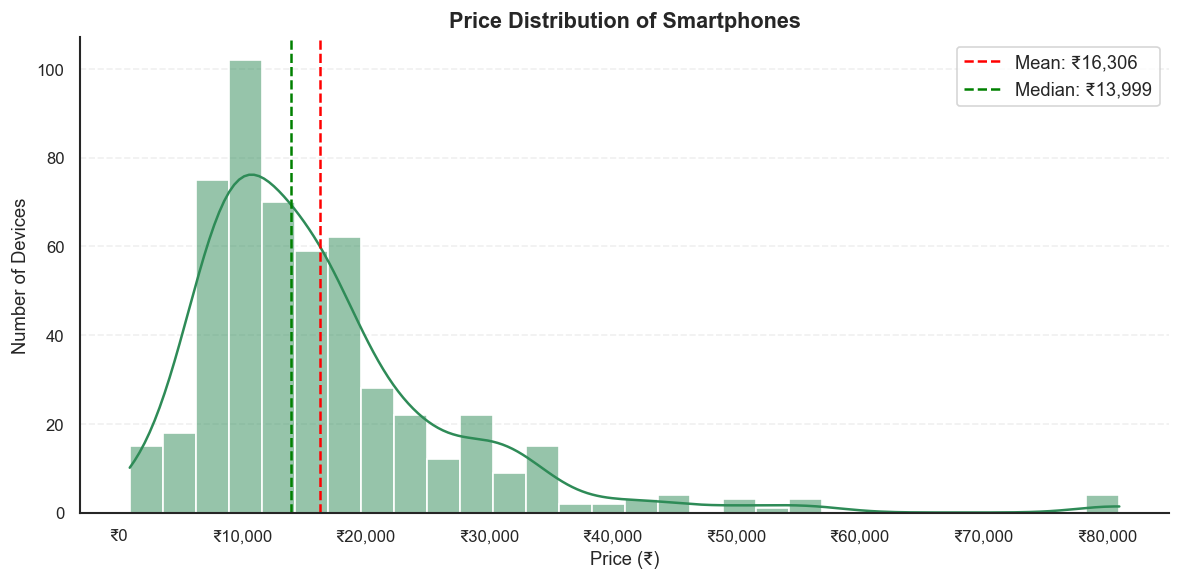

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['Price'], bins=30, kde=True, color='seagreen', edgecolor='white', ax=ax)

mean_val   = df['Price'].mean()
median_val = df['Price'].median()

ax.axvline(mean_val,   color='Red', linestyle='--', linewidth=1.5, label=f'Mean: ₹{mean_val:,.0f}')
ax.axvline(median_val, color='Green', linestyle='--', linewidth=1.5, label=f'Median: ₹{median_val:,.0f}')

ax.set_title('Price Distribution of Smartphones')
ax.set_xlabel('Price (₹)')
ax.set_ylabel('Number of Devices')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

* Price distribution shows most phones are concentrated in the lower to mid price range, mainly between ₹8,000 and ₹20,000.
* The median price (₹13,999) is lower than the mean (₹16,306), which shows some high-price phones pull the average up.
* The distribution is right-skewed, with a small number of premium devices going up to ₹80,000, while most devices stay in the budget and mid-range segment.

#### B. RAM distribution

In [65]:
print(df['RAM'].describe().round(2))

count    531.00
mean       5.40
std        1.99
min        2.00
25%        4.00
50%        6.00
75%        8.00
max        8.00
Name: RAM, dtype: float64


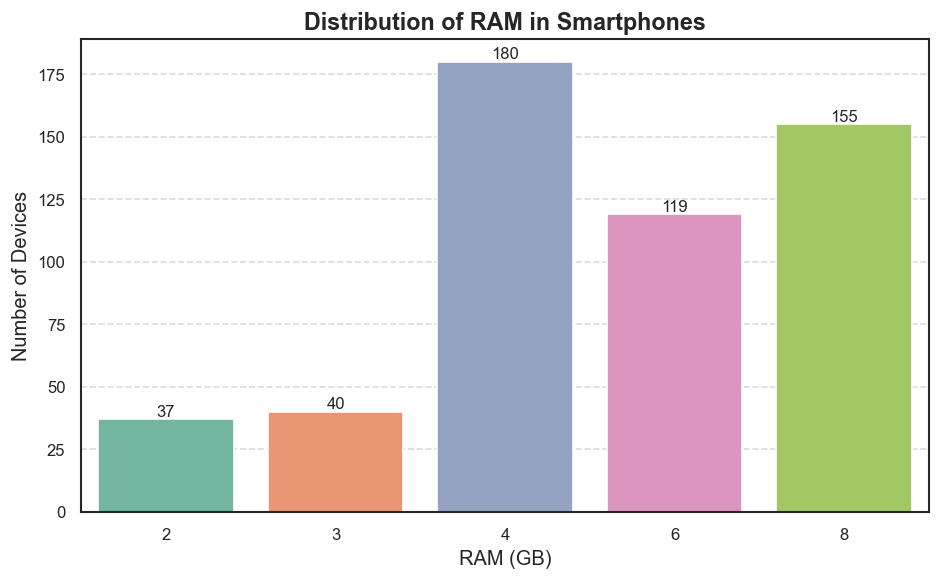

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.countplot(x='RAM', data=df, hue='RAM', palette='Set2', legend=False)

plt.title('Distribution of RAM in Smartphones', fontsize=14, weight='bold')
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Number of Devices', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* RAM values range from 2GB to 8GB, with an average around 5.4GB. Most phones are concentrated in 4GB, 6GB, and 8GB categories.
* 4GB has the highest number of devices (180), followed by 8GB (155) and 6GB (119), which shows these are the most common configurations in the dataset.
* Lower RAM options like 2GB and 3GB are much less common.

#### C. Memory Distribution

In [67]:
print(df['Memory'].describe().round(2))

count    531.00
mean     110.92
std       60.87
min       16.00
25%       64.00
50%      128.00
75%      128.00
max      256.00
Name: Memory, dtype: float64


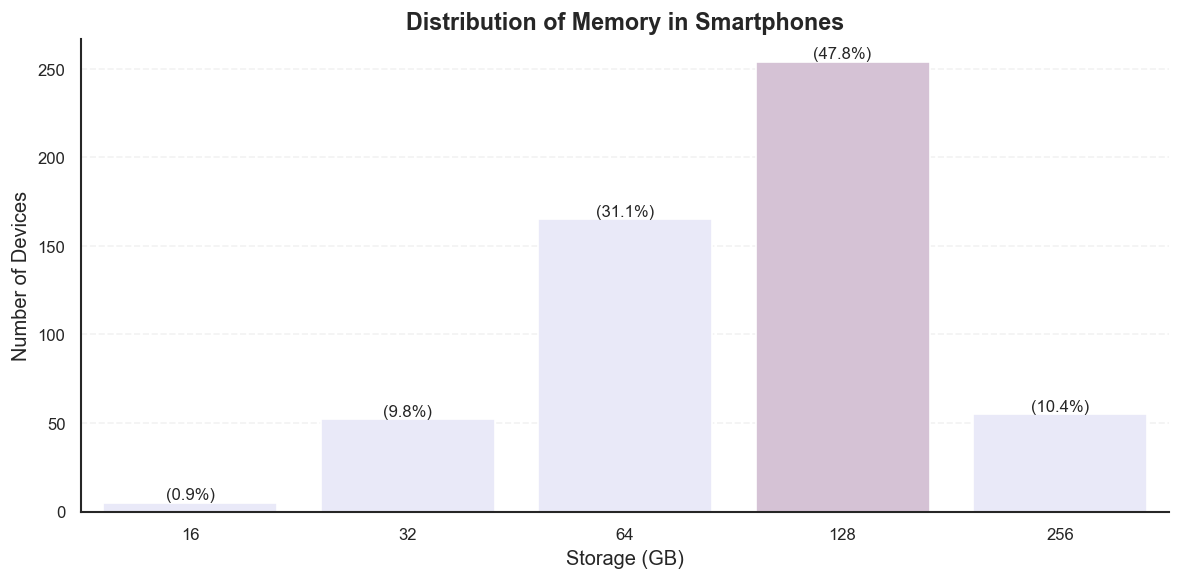

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))

order = sorted(df['Memory'].unique())
colors = ['Lavender'] * len(order)
colors[order.index(128)] = 'Thistle'
palette_dict = dict(zip(order, colors))

ax = sns.countplot(x='Memory', data=df, order=order, hue='Memory',
                   palette=palette_dict, legend=False)

total = len(df)
for p in ax.patches:
    count   = int(p.get_height())
    percent = (count / total) * 100
    ax.annotate(f'({percent:.1f}%)',
                (p.get_x() + p.get_width()/2., count),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Memory in Smartphones', fontsize=14, weight='bold')
plt.xlabel('Storage (GB)', fontsize=12)
plt.ylabel('Number of Devices', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

* Memory values range from 16GB to 256GB, with an average around 110GB.
* Most phones are available in 64GB and 128GB storage.
* 128GB has the highest number of devices (254, ~ 48%), followed by 64GB (165, ~ 32%). This shows these two are the most common storage options.
* Very few phones have 16GB, so these are less common in the dataset.

#### D. Battery Distribution

In [69]:
print(df['Battery'].describe().round(2))

count     531.00
mean     4873.88
std       765.88
min       800.00
25%      5000.00
50%      5000.00
75%      5000.00
max      7000.00
Name: Battery, dtype: float64


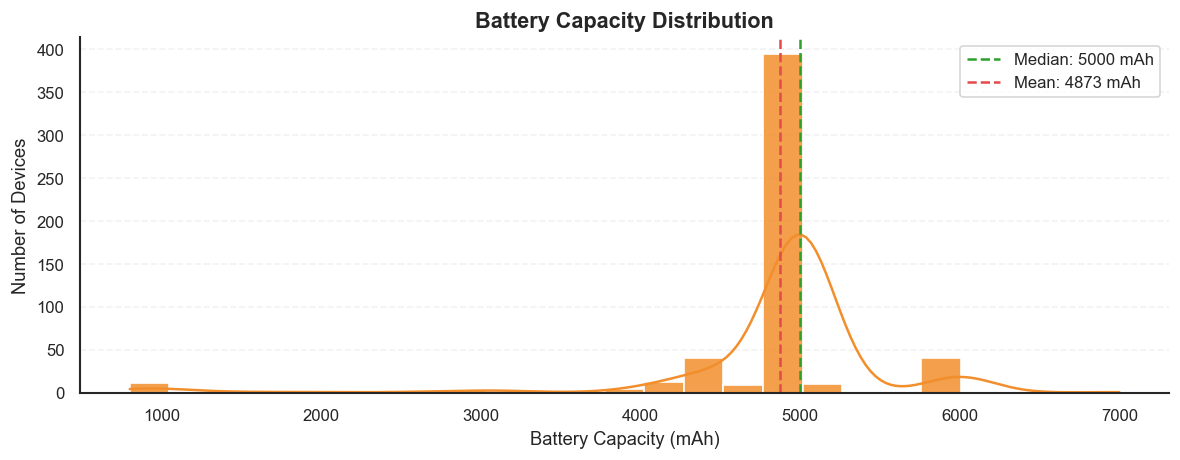

In [70]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(df['Battery'], bins=25, kde=True, color='#F28E2B',
             edgecolor='white', alpha=0.85, ax=ax)

mean_val   = df['Battery'].mean()
median_val = df['Battery'].median()

ax.axvline(median_val, color='#2CA02C', linestyle='--', linewidth=1.5, label=f'Median: {int(median_val)} mAh')
ax.axvline(mean_val,   color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Mean: {int(mean_val)} mAh')

ax.set_title('Battery Capacity Distribution', fontsize=13, weight='bold')
ax.set_xlabel('Battery Capacity (mAh)')
ax.set_ylabel('Number of Devices')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

* Battery capacity mostly stays around 5000 mAh, which is the most common value in the dataset.
* The average battery is around 4873 mAh, and most phones fall close to this range.
* The distribution shows very little variation, with a few low and high values, but most devices focus on similar battery size.
* This shows battery capacity is quite standard across phones and does not vary much compared to other features.

#### E. Mobile Height Distribution

In [71]:
print(df['Mobile Height'].describe().round(2))

count    531.00
mean      16.45
std        2.49
min        4.50
25%       16.51
50%       16.71
75%       16.94
max       41.94
Name: Mobile Height, dtype: float64


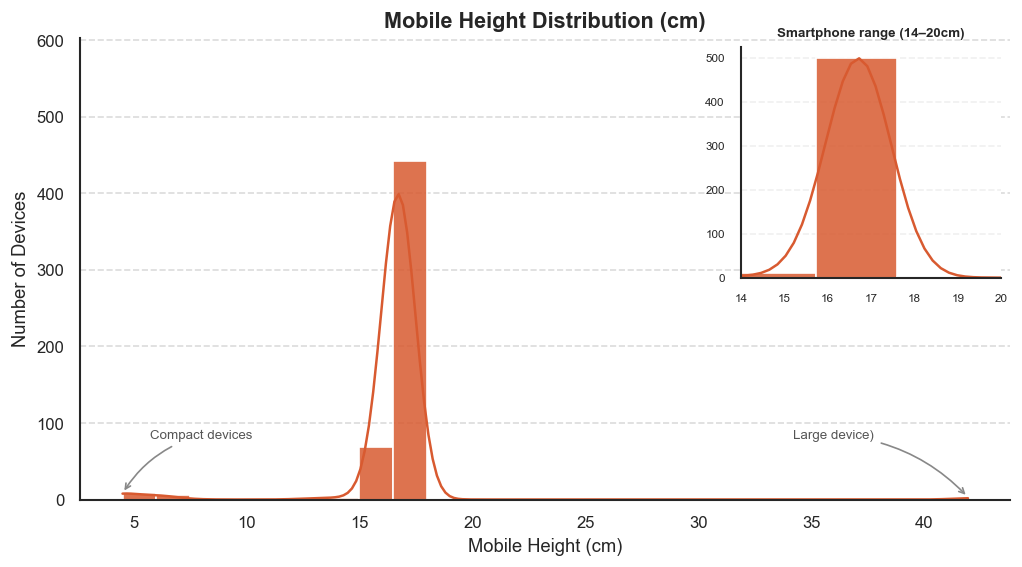

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['Mobile Height'], bins=25, kde=True,
             color='#D85A30', edgecolor='white', alpha=0.85, ax=ax)

ax.annotate('Compact devices',
            xy=(df['Mobile Height'].min(), 8), xytext=(8, 80),
            arrowprops=dict(arrowstyle='->', color='#888888', connectionstyle='arc3,rad=0.2'),
            fontsize=8, color='#555555', ha='center')

ax.annotate('Large device)',
            xy=(df['Mobile Height'].max(), 3), xytext=(36, 80),
            arrowprops=dict(arrowstyle='->', color='#888888', connectionstyle='arc3,rad=-0.2'),
            fontsize=8, color='#555555', ha='center')

ax_inset = inset_axes(ax, width="28%", height="50%", loc='upper right')
sns.histplot(df['Mobile Height'], bins=20, kde=True, color='#D85A30',
             edgecolor='white', alpha=0.85, ax=ax_inset)
ax_inset.set_xlim(14, 20)
ax_inset.set_title('Smartphone range (14–20cm)', fontsize=8)
ax_inset.set_xlabel('')
ax_inset.set_ylabel('')
ax_inset.tick_params(axis='both', labelsize=7)
ax_inset.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(ax=ax_inset)

ax.set_title('Mobile Height Distribution (cm)', fontsize=13, weight='bold')
ax.set_xlabel('Mobile Height (cm)')
ax.set_ylabel('Number of Devices')
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.subplots_adjust()
plt.show()

* Mobile height mostly stays in a very tight range between 16 and 17 cm, with an average of 16.45 cm and very low variation.
* This shows that most smartphones follow a standard size and design.
* The distribution is highly concentrated, with very few devices outside this range.
* A few extreme values like very small (around 4.5 cm) and very large (above 40 cm) appear, but these are rare and likely special cases.
* This clearly shows that mobile height does not play a major role in price or differentiation, since almost all devices have a similar size.

#### F. Camera Score Distribution

In [73]:
print(df['camera_score'].describe().round(3))

count    531.0
mean      2.16
std      1.337
min        0.0
25%      1.029
50%      1.917
75%      2.583
max       10.0
Name: camera_score, dtype: Float64


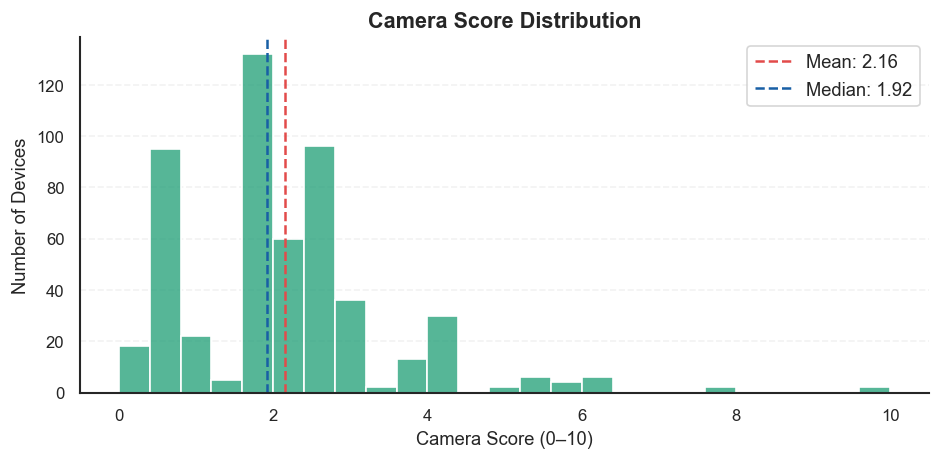

In [74]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df['camera_score'], bins=25, color='#1D9E75', edgecolor='white', ax=ax)

mean_cam   = df['camera_score'].mean()
median_cam = df['camera_score'].median()

ax.axvline(mean_cam,   color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Mean: {mean_cam:.2f}')
ax.axvline(median_cam, color='#185FA5', linestyle='--', linewidth=1.5, label=f'Median: {median_cam:.2f}')

ax.set_title('Camera Score Distribution', fontsize=13, weight='bold')
ax.set_xlabel('Camera Score (0–10)')
ax.set_ylabel('Number of Devices')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

* Camera score mostly stays on the lower side, with an average of 2.16 and median around 1.92.
* This shows most phones in the dataset have basic to moderate camera quality.
* The distribution is slightly right-skewed, where a small number of phones have high camera scores (up to 10), but most devices are concentrated between 1 and 3.
* This means high-end camera phones are limited, while the majority fall in the budget and mid camera range.
* There are also some phones with a score of 0, which shows devices with no camera or very basic camera setup.
* Overall, camera quality varies, but only few devices reach high camera performance levels.

#### G. Top 10 Brands by Device Count

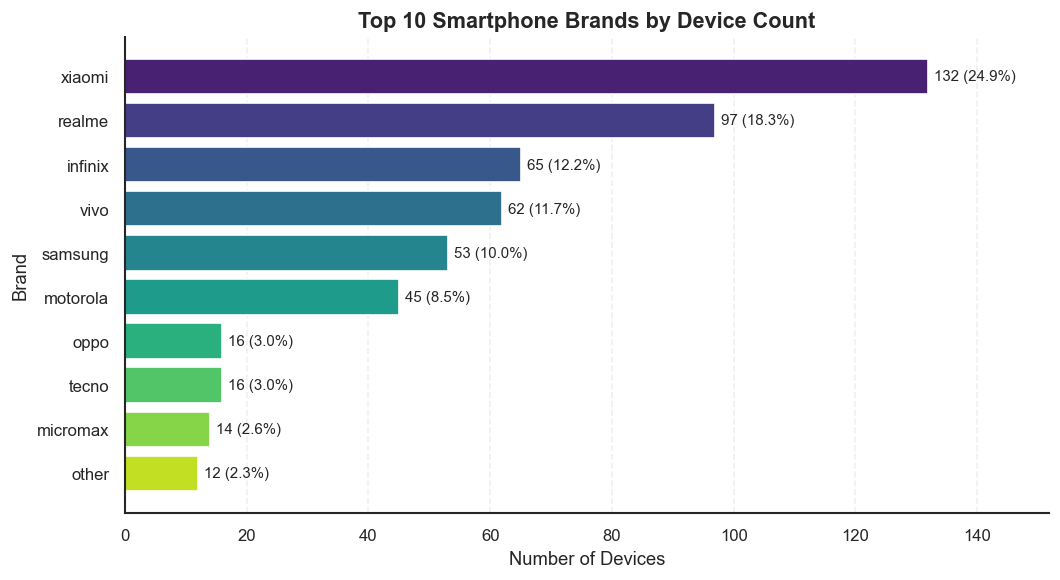

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

brand_counts = df['brand'].value_counts().head(10)
total        = df.shape[0]
colors       = sns.color_palette('viridis', len(brand_counts))

bars = ax.barh(brand_counts.index, brand_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, brand_counts.values):
    pct = (val / total) * 100
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_title('Top 10 Smartphone Brands by Device Count', fontsize=13, weight='bold')
ax.set_xlabel('Number of Devices')
ax.set_ylabel('Brand')
ax.set_xlim(0, max(brand_counts.values) * 1.15)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

* Brand distribution shows Xiaomi has the highest number of devices (132, ~24.9%), followed by Realme (97, ~18.3%) and Infinix (65, ~12.2%). These brands dominate the dataset.
* Vivo and Samsung also have strong presence, while brands like Motorola, Oppo, and Tecno have moderate counts.
* Very few devices come from Micromax and “other” brands.
* This shows the dataset is mainly focused on a few major brands, especially Xiaomi and Realme, which can influence overall analysis results.

#### H. Processor Family Distribution

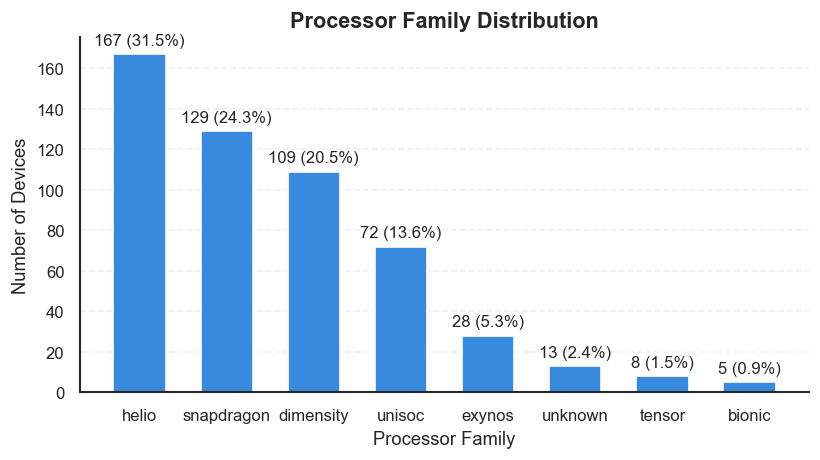

In [76]:
fig, ax = plt.subplots(figsize=(7, 4))

proc_counts = df['proc_family'].value_counts()
total       = proc_counts.sum()

bars = ax.bar(proc_counts.index, proc_counts.values,
              color='#378ADD', edgecolor='white', width=0.6)

for bar, val in zip(bars, proc_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val} ({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Processor Family Distribution', fontsize=13, weight='bold')
ax.set_xlabel('Processor Family')
ax.set_ylabel('Number of Devices')
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

* Processor distribution shows Helio has the highest number of devices (167, ~31.5%), followed by Snapdragon (129, ~24.3%) and Dimensity (109, ~20.5%). These three dominate the dataset.
* Unisoc also has a noticeable share, while Exynos, Tensor, and Bionic appear in very small numbers. This shows most phones use mid-range processors like Helio, Snapdragon, and Dimensity, while premium processors are limited.
* This indicates the dataset is more focused on budget and mid-range devices rather than high-end flagship phones.

#### I. Price Tier Distribution

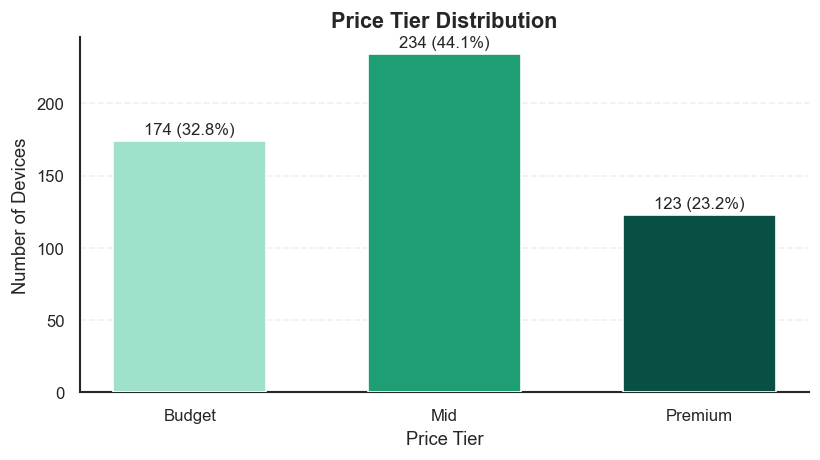

In [77]:
fig, ax = plt.subplots(figsize=(7, 4))

order    = ['Budget', 'Mid', 'Premium']
pt_counts = df['price_tier'].value_counts().reindex(order)
total    = pt_counts.sum()

bars = ax.bar(order, pt_counts.values,
              color=['#9FE1CB', '#1D9E75', '#085041'],
              edgecolor='white', width=0.6, zorder=3)

for bar, val in zip(bars, pt_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (total * 0.005),
            f'{val} ({val/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Price Tier Distribution', fontsize=13, weight='bold')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Number of Devices')
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

* Price tier distribution shows most phones fall in the Mid segment (234, ~ 44.1%), followed by Budget (174, ~ 32.8%) and Premium (123, ~ 23.2%).
* This shows the dataset is mainly focused on mid-range devices, with fewer premium phones. Budget phones also have a strong presence, while high-end devices are limited.
* This distribution helps explain why most features and patterns in the dataset reflect mid-range and budget segments more than premium ones.

#### J. 5G vs Non-5G Split

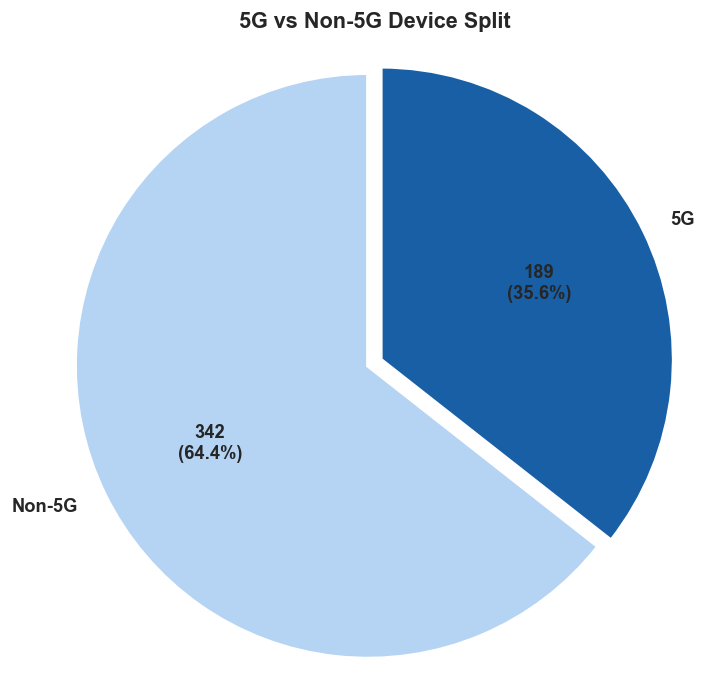

In [78]:
fig, ax = plt.subplots(figsize=(6, 6))

g_counts = df['is_5g'].value_counts().reindex([0, 1])

def autopct_format(pct):
    val = int(round(pct * g_counts.sum() / 100))
    return f'{val}\n({pct:.1f}%)'

ax.pie(g_counts, labels=['Non-5G', '5G'], autopct=autopct_format,
       startangle=90, colors=['#B5D4F4', '#185FA5'],
       explode=[0, 0.05],
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 11, 'fontweight': 'bold'})

ax.set_title('5G vs Non-5G Device Split')
ax.axis('equal')
plt.tight_layout()
plt.show()

* Most devices are non-5G (342, ~ 64.4%), while 5G devices are fewer (189, ~ 35.6%). This shows the dataset still has a larger share of older or budget phones without 5G support.
* 5G devices are present but not dominant, which means analysis results may be slightly more influenced by non-5G phones.

### K. AI Lens Distribution

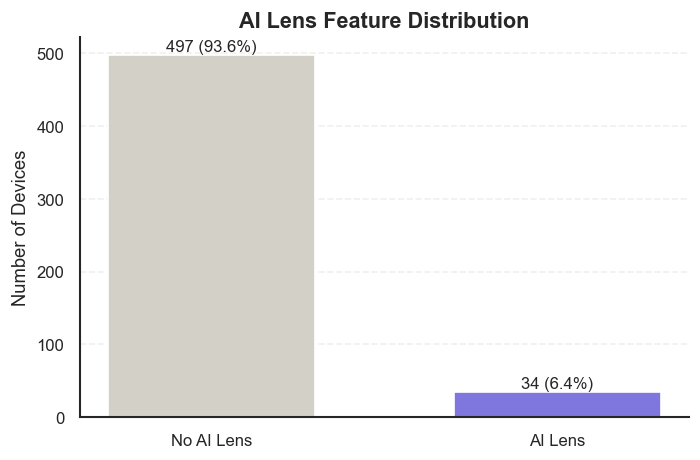

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))

ai_counts = df['AI Lens'].value_counts().reindex([0, 1])
total     = ai_counts.sum()

bars = ax.bar(['No AI Lens', 'AI Lens'], ai_counts.values,
              color=['#D3D1C7', '#7F77DD'], edgecolor='white', width=0.6)

for bar, val in zip(bars, ai_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (total * 0.01),
            f'{val} ({val/total*100:.1f}%)', ha='center', fontsize=10)

ax.set_title('AI Lens Feature Distribution', fontsize=13, weight='bold')
ax.set_ylabel('Number of Devices')
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

* Most devices do not have AI Lens (497, ~ 93.6%), while only a very small number of phones include this feature (34, ~ 6.4%).
* This shows AI Lens is not a common feature in the dataset and appears only in a few devices, so it does not play a major role in overall analysis.

#### L. Camera Tier Distribution

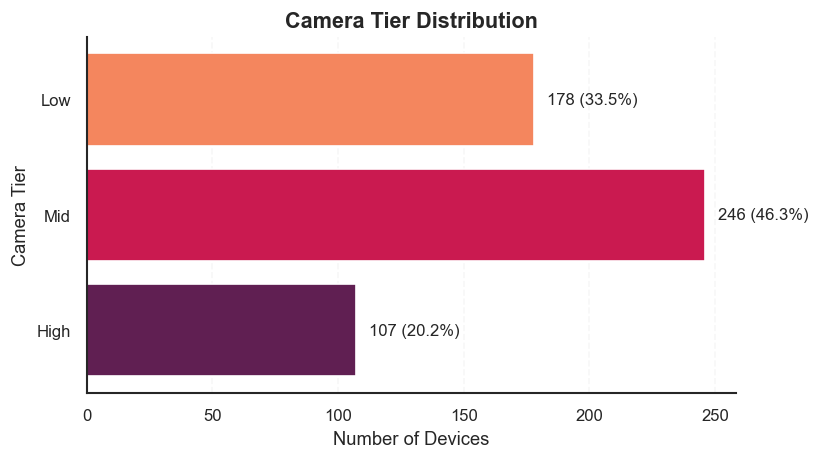

In [80]:
fig, ax = plt.subplots(figsize=(7, 4))

order    = ['Low', 'Mid', 'High']
ct_counts = df['camera_tier'].value_counts().reindex(order)
total    = ct_counts.sum()
colors   = sns.color_palette('rocket_r', len(order))

bars = ax.barh(order, ct_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, ct_counts.values):
    ax.text(val + (total * 0.01), bar.get_y() + bar.get_height() / 2,
            f'{val} ({val/total*100:.1f}%)', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_title('Camera Tier Distribution', fontsize=13, weight='bold')
ax.set_xlabel('Number of Devices')
ax.set_ylabel('Camera Tier')
ax.grid(axis='x', linestyle='--', alpha=0.15)
sns.despine()
plt.tight_layout()
plt.show()

* Most phones fall in the Mid camera tier (246, ~ 46.3%), followed by Low (178, ~ 33.5%) and High (107, ~ 20.2%).
* This shows that most devices offer average camera quality, while high-end camera phones are fewer.
* The dataset is more focused on mid and low camera performance rather than premium camera devices.

---

### 4. Outlier Detection using the IQR Method
* IQR rule: `Lower = Q1 − 1.5×IQR`, `Upper = Q3 + 1.5×IQR`
* The IQR Method is used because the price distribution is right-skewed. IQR is percentile-based and works well for non-normal distributions.

In [81]:
numeric_cols = ['Price', 'RAM', 'Memory', 'Battery', 'Mobile Height',
               'rear_camera_mp', 'front_camera_mp', 'camera_score']

results = []
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        results.append({'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': 0,
                        'Lower Bound': None, 'Upper Bound': None,
                        'Outlier Count': '—', 'Outlier %': '—'})
        continue

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    results.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                    'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
                    'Upper Bound': round(upper,2),
                    'Outlier Count': n_out, 'Outlier %': round(n_out/len(df)*100,1)})

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

         Column      Q1       Q3     IQR  Lower Bound  Upper Bound Outlier Count Outlier %
          Price 9368.00 19338.50 9970.50     -5587.75     34294.25            25       4.7
            RAM    4.00     8.00    4.00        -2.00        14.00             0       0.0
         Memory   64.00   128.00   64.00       -32.00       224.00            55      10.4
        Battery 5000.00  5000.00    0.00          NaN          NaN             —         —
  Mobile Height   16.51    16.94    0.43        15.87        17.58            32       6.0
 rear_camera_mp   13.00    50.00   37.00       -42.50       105.50            39       7.3
front_camera_mp    5.00    16.00   11.00       -11.50        32.50            13       2.4
   camera_score    1.03     2.58    1.55        -1.30         4.91            22       4.1


* Outliers are checked using IQR to find extreme values that fall far from the normal range without being affected by skewed data.
* Price shows some outliers (~ 4.7%), which means a few very high or low-priced phones exist outside the normal range.
* RAM and Memory do not show outliers, which means these values are clean and consistent.
* Battery shows IQR = 0, so lower and upper bounds are not defined. This happens because most phones have the same battery value (around 5000 mAh), so there is no spread in the middle 50% of data. Because of this, outlier detection does not apply to batteries.
* Mobile Height, rear camera, front camera, and camera score show some outliers, which means a few devices have unusual values compared to the majority.
* This helps in understanding which features are stable and which ones need careful handling during analysis.

In [82]:
def get_outliers(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    return outliers, lower, upper

def plot_boxplot(df, col, title, xlabel):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    sns.boxplot(x=df[col], ax=ax, color='#E8F4FD', linewidth=1.5, width=0.45,
                flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                                markeredgecolor='#C0392B', markersize=5, alpha=0.7),
                medianprops=dict(color='#185FA5', linewidth=2.5),
                whiskerprops=dict(color='#555555', linewidth=1.2),
                capprops=dict(color='#555555', linewidth=1.5),
                boxprops=dict(edgecolor='#378ADD', linewidth=1.2))

    if lower >= 0:
        ax.axvline(lower, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6,
                   label=f'Lower bound: {lower:,.0f}')
    ax.axvline(upper, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6,
               label=f'Upper bound: {upper:,.0f}')

    ax.legend(frameon=True, fontsize=9, handlelength=0, handletextpad=0,
              edgecolor='#cccccc', framealpha=0.9)

    ax.set_title(title, fontsize=13, weight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_yticks([])
    ax.grid(axis='x', linestyle='--', alpha=0.15, zorder=0)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

In [83]:
df_before = df.copy()

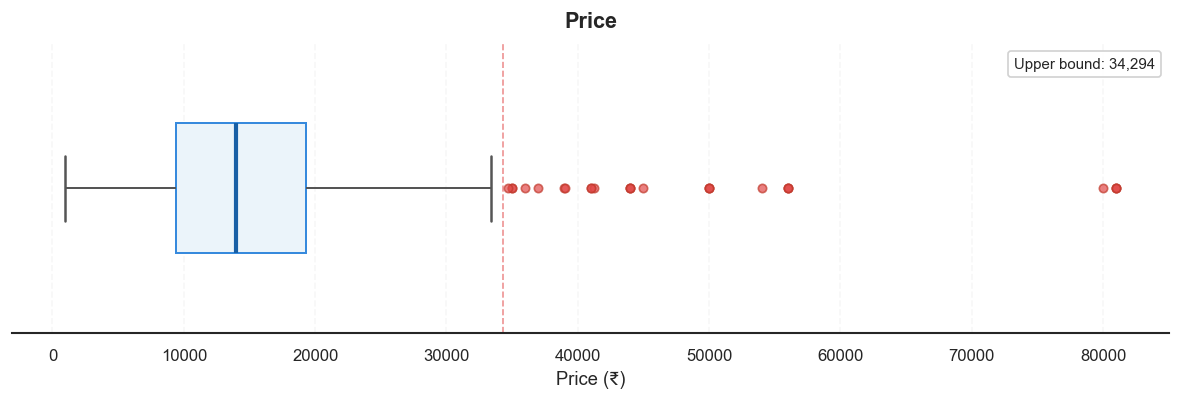

In [84]:
plot_boxplot(df, 'Price', 'Price', 'Price (₹)')

In [85]:
outliers, lower, upper = get_outliers(df, 'Price')
print(f"IQR Lower bound : ₹{lower:,.0f}")
print(f"IQR Upper bound : ₹{upper:,.0f}")
print(f"Total outliers: {outliers.shape[0]}")

print("\n Devices with Price < ₹4000 (low-price entries):")
low_price = df[df['Price'] < 4000]
print(f"Count: {low_price.shape[0]}")
print(low_price[['Model', 'brand', 'RAM', 'Memory',
                 'rear_camera_mp', 'front_camera_mp', 'Price']].to_string(index=False))

IQR Lower bound : ₹-5,588
IQR Upper bound : ₹34,294
Total outliers: 25

 Devices with Price < ₹4000 (low-price entries):
Count: 15
         Model    brand  RAM  Memory  rear_camera_mp  front_camera_mp  Price
Micromax IN 2C micromax    6     128               0                0   1449
    micromax 2 micromax    8     128               2                0   1849
      micromax micromax    4     128               0                0   1422
    micromax 1 micromax    8     256               0                0   1299
    Micromax 3 micromax    4     128               2                0   2615
    micromax 3 micromax    4      64               2                0   2490
    micromax 2 micromax    8     256               0                0   1299
    micromax 3 micromax    4     256               2                0   2499
      micromax micromax    3      32               0                0   1375
     micromax1 micromax    3      32               0                0   1599
    micromax 2 microma

* Most phones stay in the budget and mid-range, while a small group sits at a much higher price. These higher values include phones like the iPhone, the Samsung S series, and the Google Pixel. These are premium devices, so their high price is expected.
* These outliers are not errors. They clearly represent the premium segment of the market. This shows that the dataset includes both budget and high-end phones, which is important for proper analysis.
* Some phones near ₹35k–₹40k appear close to the boundary, but they still follow a normal pricing pattern. They are not unusual and do not indicate any issue.So, we keep all price outliers.
* We keep them because they reflect real market behavior. Removing them hides the premium segment and makes the analysis incomplete.
* Very low-price phones (below ₹4,000) show different behavior. Many of these devices have 0 MP cameras and unusual specifications. This indicates they are feature phones or incorrect entries, not real smartphones.

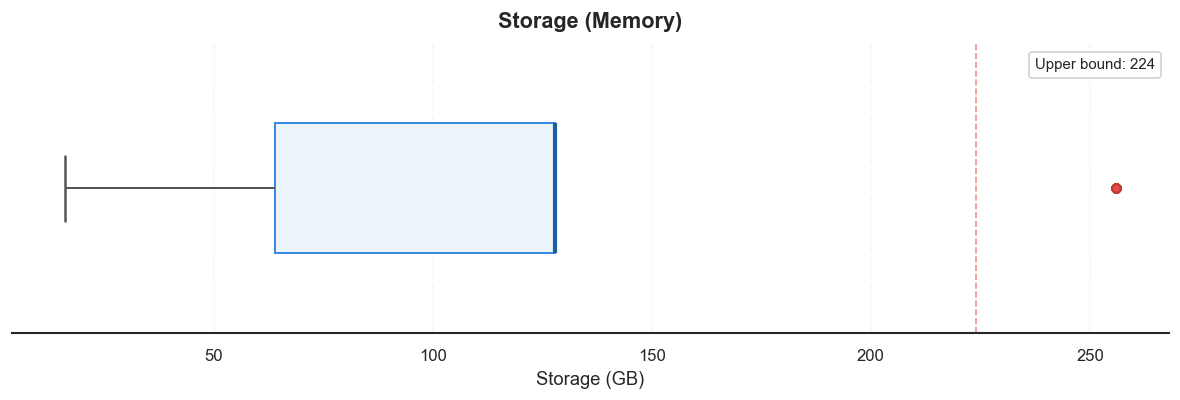

In [86]:
plot_boxplot(df, 'Memory', 'Storage (Memory)', 'Storage (GB)')

In [87]:
outliers, lower, upper = get_outliers(df, 'Memory')
print(f"Total outliers: {outliers.shape[0]}")
print(outliers.sort_values('Memory', ascending=False)[
    ['Model', 'brand', 'RAM', 'Memory', 'Price']
].head(10).to_string(index=False))

Total outliers: 55
                     Model    brand  RAM  Memory  Price
          MOTOROLA Edge 40 motorola    8     256  29999
                 OnePlus 8  oneplus    8     256  38920
Infinix Zero 5G 2023 TURBO  infinix    8     256  17999
     REDMI Note 12 Pro+ 5G   xiaomi    4     256  32999
               vivo V23 5G     vivo    4     256  27540
     SAMSUNG Galaxy A34 5G  samsung    8     256  32999
               vivo V27 5G     vivo    4     256  36999
    MOTOROLA Edge 30 Ultra motorola    4     256  49999
                POCO F5 5G   xiaomi    4     256  32999
                POCO F5 5G   xiaomi    8     256  32999


* Most phones come with 32GB, 64GB, and 128GB storage. A large number of phones also come with 256GB storage. Because of this, the upper limit comes around 224GB, and all 256GB phones appear as outliers.
* After checking the actual rows, it shows that these outliers are all 256GB devices from brands like Xiaomi, Samsung, Vivo, and Motorola. These are modern smartphones, and their storage size is valid. So these outliers are not errors. They clearly show a higher storage segment in the market.
* This happens because IQR treats 256GB as far from the middle values, but in reality, 256GB is a common high-end configuration.
* They represent real product offerings. Removing them will remove high-storage phones and make the dataset incomplete.

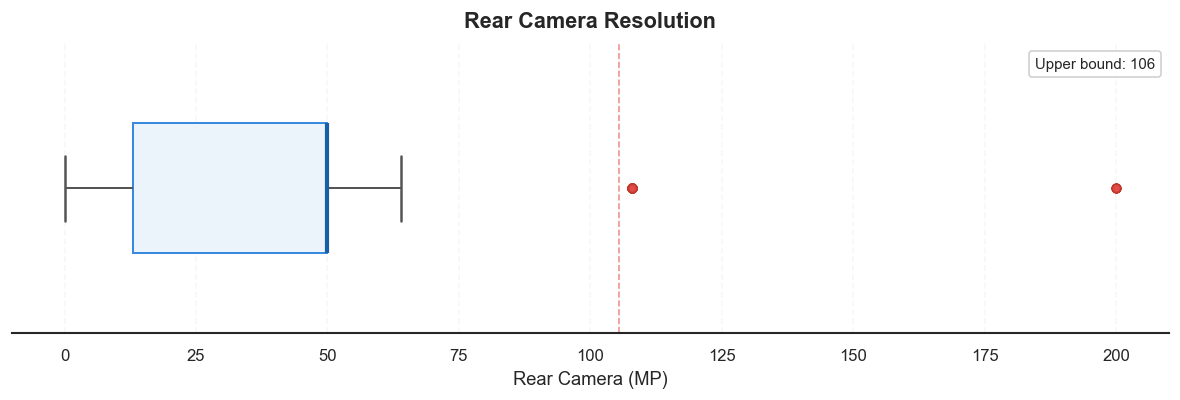

In [88]:
plot_boxplot(df, 'rear_camera_mp', 'Rear Camera Resolution', 'Rear Camera (MP)')

In [89]:
outliers, lower, upper = get_outliers(df, 'rear_camera_mp')
print(f"Total outliers: {outliers.shape[0]}")
print(outliers.sort_values('rear_camera_mp', ascending=False)[
    ['Model', 'brand', 'rear_camera_mp', 'Price']
].head(10).to_string(index=False))

print(f"\n Devices with 0 MP rear camera: {(df['rear_camera_mp'] == 0).sum()}")
print(df[df['rear_camera_mp'] == 0][
    ['Model', 'brand', 'rear_camera_mp', 'front_camera_mp', 'Price']
].to_string(index=False))

Total outliers: 39
                 Model    brand  rear_camera_mp  Price
 REDMI Note 12 Pro+ 5G   xiaomi             200  32999
 REDMI Note 12 Pro+ 5G   xiaomi             200  29999
 REDMI Note 12 Pro+ 5G   xiaomi             200  32999
 REDMI Note 12 Pro+ 5G   xiaomi             200  32999
MOTOROLA Edge 30 Ultra motorola             200  49999
MOTOROLA Edge 30 Ultra motorola             200  49999
 REDMI Note 12 Pro+ 5G   xiaomi             200  29999
 REDMI Note 12 Pro+ 5G   xiaomi             200  29999
        OPPO Reno8T 5G     oppo             108  29999
     realme 10 Pro+ 5G   realme             108  23999

 Devices with 0 MP rear camera: 9
         Model    brand  rear_camera_mp  front_camera_mp  Price
Micromax IN 2C micromax               0                0   1449
      micromax micromax               0                0   1422
    micromax 1 micromax               0                0   1299
    micromax 2 micromax               0                0   1299
      micromax microm

* High rear camera values like 108MP and 200MP appear as outliers, but these are real premium phones. They are not errors.
* These high values belong to devices like the Redmi Note Pro series and the Motorola Edge series. These phones are known for strong camera features. So, these high camera values are valid, and we keep them in the dataset.
* Some devices show a 0MP rear camera. These are not normal smartphones. These phones also have a very low price and no front camera. This clearly shows they are feature phones. Since this dataset is for smartphones, these devices do not belong here.
* These 0MP entries can affect the analysis if we keep them. We handle them later during data cleaning.

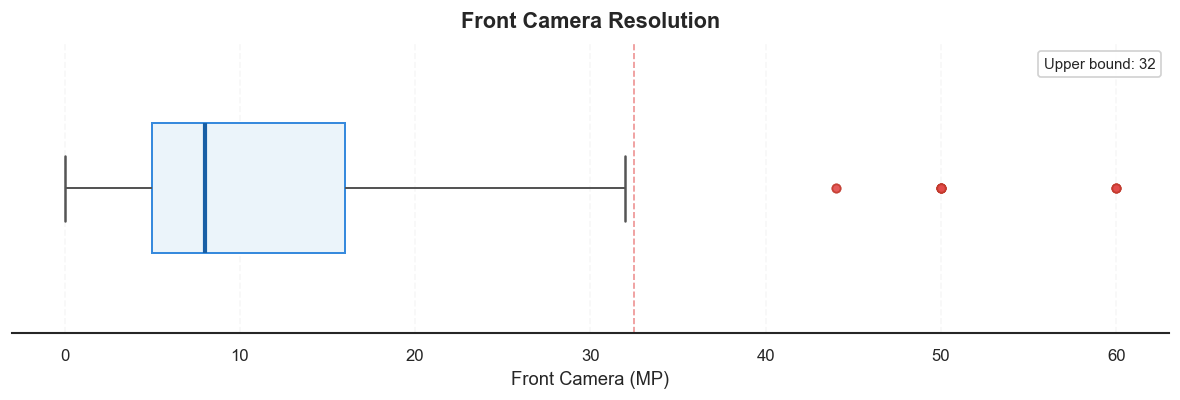

In [90]:
plot_boxplot(df, 'front_camera_mp', 'Front Camera Resolution', 'Front Camera (MP)')

In [91]:
outliers, lower, upper = get_outliers(df, 'front_camera_mp')
print(f"Total outliers: {outliers.shape[0]}")
print(outliers.sort_values('front_camera_mp', ascending=False)[
    ['Model', 'brand', 'front_camera_mp', 'Price']
].head(10).to_string(index=False))

print(f"\n Devices with 0MP front camera: {(df['front_camera_mp'] == 0).sum()}")

# Feature phone identification
feature_phones_cam = df[
    (df['rear_camera_mp'] == 0) &
    (df['front_camera_mp'] == 0)
]
print(f"\n Devices with BOTH cameras at 0MP: {feature_phones_cam.shape[0]}")
print(feature_phones_cam[
    ['Model', 'brand', 'rear_camera_mp', 'front_camera_mp', 'Price', 'Mobile Height']
].to_string(index=False))

Total outliers: 13
                 Model    brand  front_camera_mp  Price
       Infinix Zero 20  infinix               60  15999
       Infinix Zero 20  infinix               60  15999
MOTOROLA Edge 30 Ultra motorola               60  49999
MOTOROLA Edge 30 Ultra motorola               60  49999
           vivo V27 5G     vivo               50  32999
           vivo V27 5G     vivo               50  32999
           vivo V23 5G     vivo               50  27540
           vivo V27 5G     vivo               50  36999
           vivo V25 5G     vivo               50  27999
           vivo V25 5G     vivo               50  27999

 Devices with 0MP front camera: 15

 Devices with BOTH cameras at 0MP: 9
         Model    brand  rear_camera_mp  front_camera_mp  Price  Mobile Height
Micromax IN 2C micromax               0                0   1449           4.50
      micromax micromax               0                0   1422           4.50
    micromax 1 micromax               0               

* High front camera values like 50MP and 60MP appear as outliers, but these belong to modern smartphones. Many brands focus on selfie cameras, so these values are normal.
* These phones also have a mid to high price, which supports that they are real devices, not errors. So, these high front camera values are valid, and we keep them.
* Some devices show 0MP front camera. When both front and rear cameras are 0MP, these are not smartphones. These are feature phones. These devices also have very low height and low price, which confirms they are not part of the smartphone category.

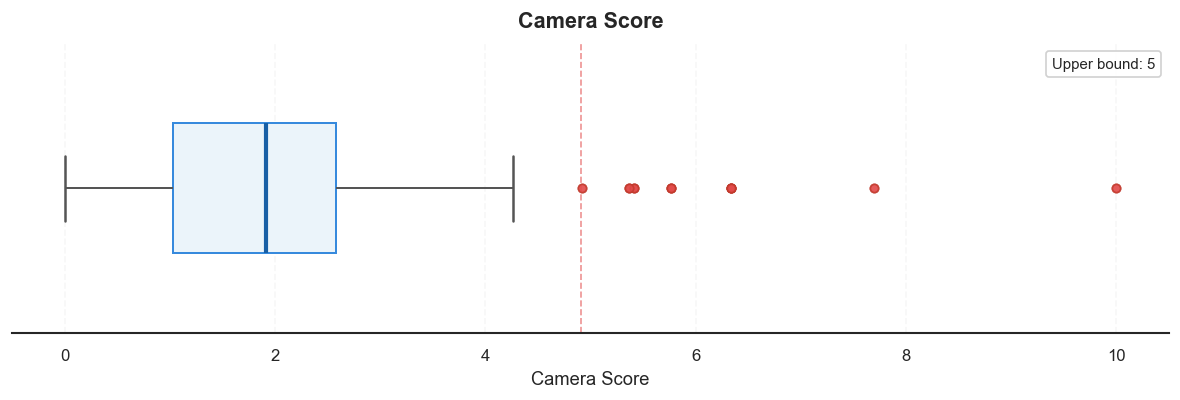

In [92]:
plot_boxplot(df, 'camera_score', 'Camera Score', 'Camera Score')

In [93]:
outliers, lower, upper = get_outliers(df, 'camera_score')
print(f"Total outliers: {outliers.shape[0]}")
print(outliers.sort_values('camera_score', ascending=False)[
    ['Model', 'brand', 'camera_score', 'Price']
].head(10).to_string(index=False))

Total outliers: 22
                 Model    brand  camera_score  Price
MOTOROLA Edge 30 Ultra motorola          10.0  49999
MOTOROLA Edge 30 Ultra motorola          10.0  49999
       Infinix Zero 20  infinix           7.7  15999
       Infinix Zero 20  infinix           7.7  15999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  29999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  29999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  32999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  32999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  32999
 REDMI Note 12 Pro+ 5G   xiaomi      6.333333  29999


* Most phones stay in the low to mid camera score range, and the upper limit comes around 5. Phones with higher scores, like 6, 7, and 10, appear as outliers.
* These phones have high camera specifications, so their score becomes higher. So these outliers are not errors. They come from phones with a strong camera setup.
* This happens because most phones in the dataset belong to the budget and mid-range, so higher scores look far from the normal range.
* Camera score outliers represent phones with strong camera performance. These values are valid and important for analysis.

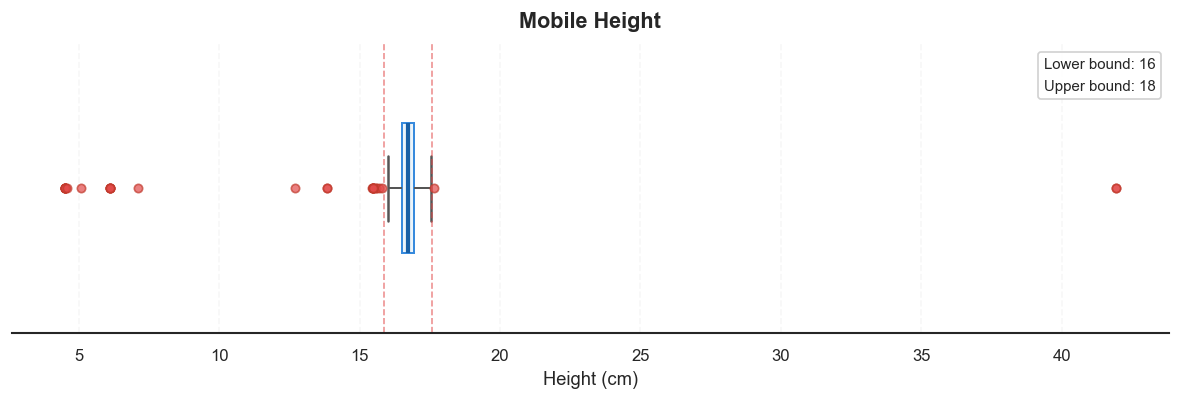

In [94]:
plot_boxplot(df, 'Mobile Height', 'Mobile Height', 'Height (cm)')

In [95]:
print("Devices below 10 cm (feature phones / invalid):")
print(df[df['Mobile Height'] < 10][
    ['Model', 'Mobile Height', 'Price', 'rear_camera_mp', 'front_camera_mp']
].sort_values('Mobile Height').to_string(index=False))

print("\n Devices above 20 cm (data entry error):")
print(df[df['Mobile Height'] > 20][
    ['Model', 'Mobile Height', 'Price']
].to_string(index=False))

print("\n Devices 10–14 cm (borderline check):")
print(df[(df['Mobile Height'] >= 10) & (df['Mobile Height'] < 14)][
    ['Model', 'Mobile Height', 'Price', 'rear_camera_mp', 'front_camera_mp']
].sort_values('Mobile Height').to_string(index=False))

Devices below 10 cm (feature phones / invalid):
         Model  Mobile Height  Price  rear_camera_mp  front_camera_mp
Micromax IN 2C           4.50   1449               0                0
      micromax           4.50   1422               0                0
    micromax 1           4.50   1299               0                0
    micromax 2           4.50   1299               0                0
      micromax           4.50   1375               0                0
     micromax1           4.50   1599               0                0
    redmi mono           4.50   1699               0                0
     redmi min           4.57    920               0                0
    micromax 3           5.08   2490               2                0
    Micromax 3           6.10   2615               2                0
    micromax 3           6.10   2499               2                0
    micromax 2           6.10   2499               2                0
     redmi max           6.10   3549      

* Most smartphones fall within a normal height range of around 15 cm to 18 cm, which represents standard device sizes in the market.
* However, some values fall far outside this range. Devices below 10 cm show very small heights, such as 4.5 cm to 7 cm.
* These phones also have 0 MP or very low camera values and very low prices, usually below ₹4,000. This clearly indicates that they are feature phones and not smartphones, so they do not belong in this dataset.
* On the other side, a few devices show heights above 20 cm, around 41.9 cm, which is not realistic for mobile phones and points to data entry errors.
* There are also some devices between 10 cm and 14 cm, which may look unusual at first, but they have valid camera features and reasonable pricing, so they behave like real smartphones and are kept.
* Based on this, devices below 10 cm and above 20 cm are removed, while the rest are retained.

---

### 5. Outlier Treatment

**Why not capping?** 
* Replacing 4.5cm with 15.87cm fabricates data we have no basis for. These are not outliers; they are errors and out-of-scope entries. That is a different category, and removal is the correct action.

In [96]:
before = len(df)

remove_feature_phones = df['Mobile Height'] < 10.0
remove_entry_error    = df['Mobile Height'] > 20.0

df = df[~(remove_feature_phones | remove_entry_error)].reset_index(drop=True)

after = len(df)

print(f"Rows before  : {before}")
print(f"Rows removed : {before - after}")
print(f"Rows after   : {after}")
print(f"\nMobile Height range after: {df['Mobile Height'].min():.2f} – {df['Mobile Height'].max():.2f} cm")

Rows before  : 531
Rows removed : 17
Rows after   : 514

Mobile Height range after: 12.70 – 17.65 cm


In [97]:
print("=" * 55)
print("IMPACT OF MOBILE HEIGHT CLEANING ON OTHER FEATURES")
print("=" * 55)

# Price impact
before_low  = (df_before['Price'] < 5000).sum()
after_low   = (df['Price'] < 5000).sum()
print(f"\n Low price phones (< ₹5,000):")
print(f"   Before : {before_low}")
print(f"   After  : {after_low}")
print(f"   Removed: {before_low - after_low}")

# Zero camera impact
before_cam = ((df_before['rear_camera_mp'] == 0) & 
              (df_before['front_camera_mp'] == 0)).sum()
after_cam  = ((df['rear_camera_mp'] == 0) & 
              (df['front_camera_mp'] == 0)).sum()
print(f"\n Zero camera phones (both 0 MP):")
print(f"   Before : {before_cam}")
print(f"   After  : {after_cam}")
print(f"   Removed: {before_cam - after_cam}")

# Total rows
print(f"\n Total rows:")
print(f"   Before : {len(df_before)}")
print(f"   After  : {len(df)}")
print(f"   Removed: {len(df_before) - len(df)}")

IMPACT OF MOBILE HEIGHT CLEANING ON OTHER FEATURES

 Low price phones (< ₹5,000):
   Before : 16
   After  : 1
   Removed: 15

 Zero camera phones (both 0 MP):
   Before : 9
   After  : 0
   Removed: 9

 Total rows:
   Before : 531
   After  : 514
   Removed: 17


* Mobile height cleaning removes 17 rows in total, which improves the overall data quality.
* Most of the removed rows belong to very low-price phones. Low-price devices below ₹4,000 drop from 15 to 0. This shows that these were not real smartphones.
* All phones with 0 MP front and rear camera are completely removed. These are clearly feature phones and do not fit in a smartphone dataset.
* This cleaning step does more than fix height. It also removes related issues in price and camera at the same time.
* After cleaning, the dataset becomes more consistent and better aligned with real smartphone behavior.

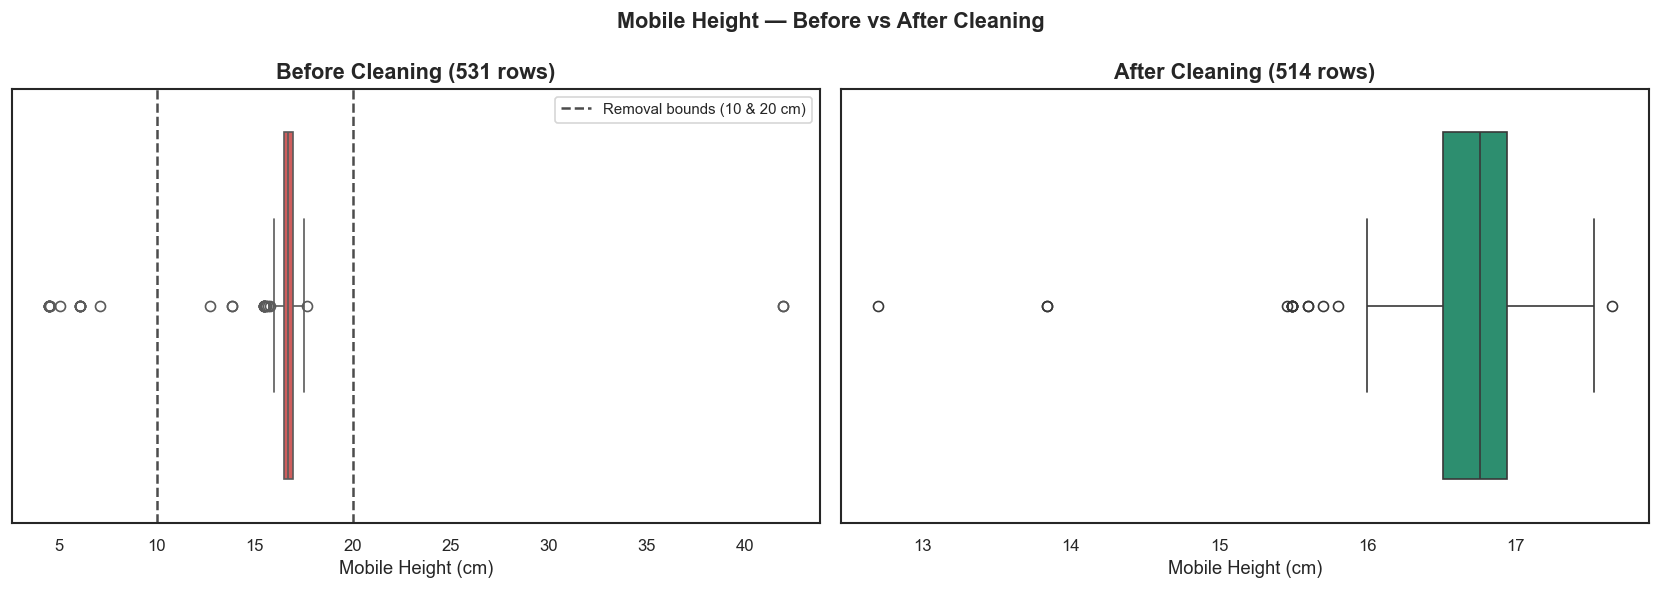

Before: 531 rows | range: 4.50 – 41.94 cm
After : 514 rows         | range: 12.70 – 17.65 cm
Removed: 17 rows


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df_before['Mobile Height'], ax=axes[0], color='#E24B4A')
axes[0].set_title(f'Before Cleaning ({len(df_before)} rows)', fontweight='bold')
axes[0].set_xlabel('Mobile Height (cm)')
axes[0].axvline(10, color='black', linestyle='--', alpha=0.7, label='Removal bounds (10 & 20 cm)')
axes[0].axvline(20, color='black', linestyle='--', alpha=0.7)
axes[0].legend(fontsize=9)

sns.boxplot(x=df['Mobile Height'], ax=axes[1], color='#1D9E75')
axes[1].set_title(f'After Cleaning ({len(df)} rows)', fontweight='bold')
axes[1].set_xlabel('Mobile Height (cm)')

plt.suptitle('Mobile Height — Before vs After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Before: {len(df_before)} rows | range: {df_before['Mobile Height'].min():.2f} – {df_before['Mobile Height'].max():.2f} cm")
print(f"After : {len(df)} rows         | range: {df['Mobile Height'].min():.2f} – {df['Mobile Height'].max():.2f} cm")
print(f"Removed: {len(df_before) - len(df)} rows")

* Before cleaning, the data spreads too wide, from 4.5 cm to 41.9 cm. This range does not match real smartphone sizes.
* After cleaning, the values become tightly grouped between 12.7 cm and 17.6 cm. This matches real device sizes in the market, and only valid variations remain, and unrealistic values are removed.
* The main cluster becomes clearer after cleaning. This shows that most smartphones follow a consistent size range.
* Extreme values on both sides reduce strongly. This helps the model focus on real patterns instead of noise.
* The distribution becomes more balanced and easier to interpret. There is less distortion from invalid entries.

---

### 6. Bivariate Analysis

#### A. RAM vs Price

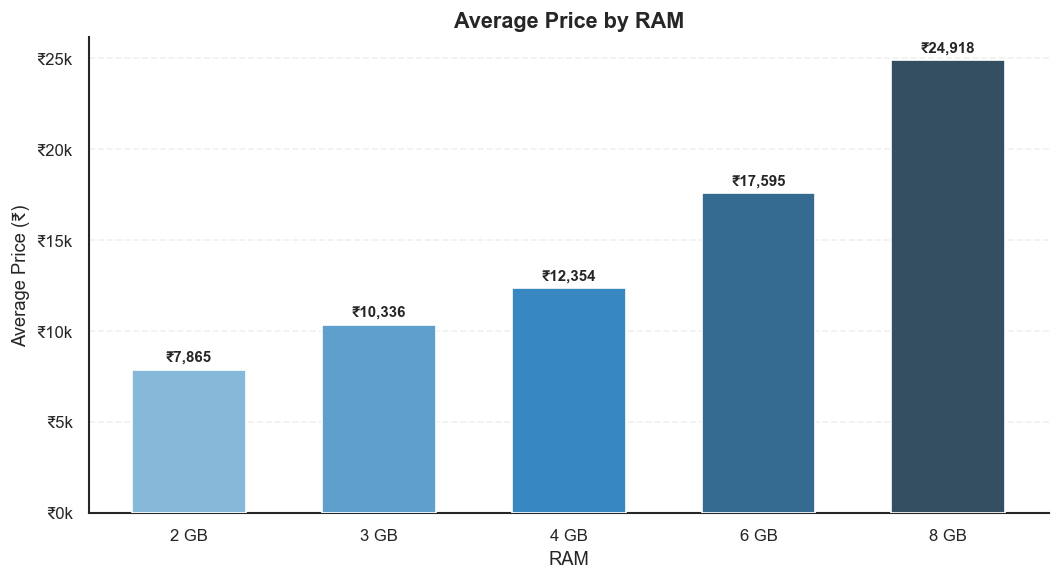

Device count per RAM tier:
RAM
2     37
3     38
4    172
6    118
8    149
Name: count, dtype: int64


In [99]:
fig, ax = plt.subplots(figsize=(9, 5))

ram_price = df.groupby('RAM')['Price'].mean().round(0).reset_index()
colors    = sns.color_palette('Blues_d', len(ram_price))

bars = ax.bar(ram_price['RAM'].astype(str) + ' GB', ram_price['Price'],
              color=colors, edgecolor='white', width=0.6, zorder=3)

for bar, val in zip(bars, ram_price['Price']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'₹{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Price by RAM', fontsize=13, fontweight='bold')
ax.set_xlabel('RAM')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

print("Device count per RAM tier:")
print(df['RAM'].value_counts().sort_index())

* Price clearly increases as RAM increases. Phones with 2GB RAM average around ₹7,865, 3GB around ₹10,336, 4GB around ₹12,354, 6GB around ₹17,595, and 8GB reach about ₹24,918. This shows a strong positive relationship — higher RAM directly connects to a higher price.
* This happens because more RAM means better performance, smoother multitasking, and better user experience, so brands charge more for it.
* Device count also supports this pattern. Most phones are in 4GB (172), 8GB (149), and 6GB (118), while very few phones exist in 2GB (37) and 3GB (38). This means the market mainly focuses on mid to high RAM devices.
* So overall, RAM is one of the strongest drivers of price, and both price trend and device distribution clearly support this.

#### B. Memory vs Price

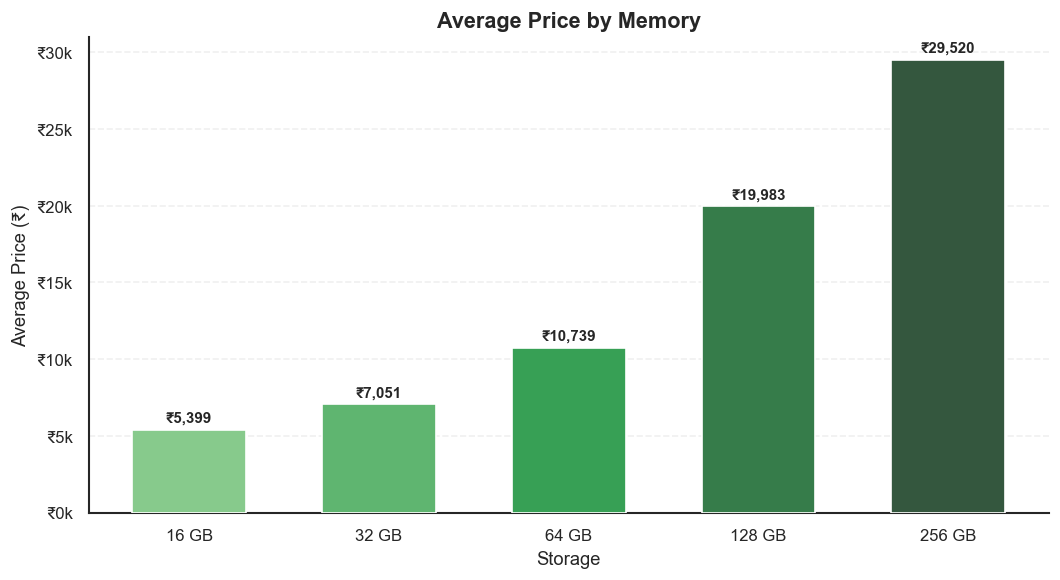

Device count per storage tier:
Memory
16       2
32      49
64     163
128    248
256     52
Name: count, dtype: int64


In [100]:
fig, ax = plt.subplots(figsize=(9, 5))

mem_price = df.groupby('Memory')['Price'].mean().round(0).reset_index().sort_values('Memory')
colors    = sns.color_palette('Greens_d', len(mem_price))

bars = ax.bar(mem_price['Memory'].astype(str) + ' GB', mem_price['Price'],
              color=colors, edgecolor='white', width=0.6, zorder=3)

for bar, val in zip(bars, mem_price['Price']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'₹{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Price by Memory', fontsize=13, fontweight='bold')
ax.set_xlabel('Storage')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

print("Device count per storage tier:")
print(df['Memory'].value_counts().sort_index())

* Price clearly increases as storage increases. Phones with 16GB cost around ₹5,399, 32GB around ₹7,051, 64GB around ₹10,739, 128GB around ₹19,983, and 256GB go up to ₹29,520. This shows a strong upward trend; higher storage directly connects to a higher price.
* This makes sense because more storage allows users to keep more apps, photos, and videos, so brands charge more for higher capacity.
* Device count also supports this pattern. Most phones are in 128GB (248) and 64GB (163), while very few phones are in 16GB (2) and 32GB (49). 256GB also has fewer devices (52), which shows it belongs more to higher-end phones.
* So overall, storage strongly impacts price, and the market mainly focuses on 64GB and 128GB, with higher storage pushing devices into the premium range.

#### C. Brand vs Price

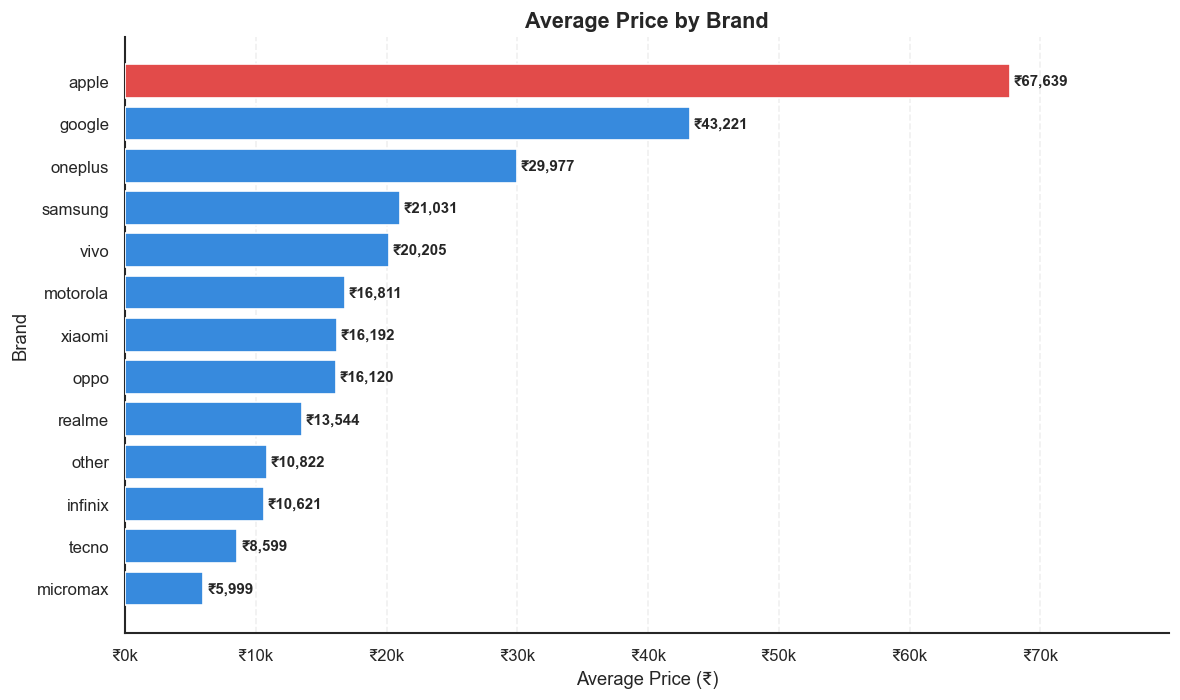

Device count per brand:
brand
xiaomi      129
realme       97
infinix      65
vivo         62
samsung      53
motorola     43
oppo         16
tecno        16
other        12
google        9
oneplus       5
apple         5
micromax      2
Name: count, dtype: int64


In [101]:
fig, ax = plt.subplots(figsize=(10, 6))

brand_price = df.groupby('brand')['Price'].mean().round(0).sort_values(ascending=True)
colors      = ['#E24B4A' if b == 'apple' else '#378ADD' for b in brand_price.index]

bars = ax.barh(brand_price.index, brand_price.values, color=colors, edgecolor='white', zorder=3)

for bar, val in zip(bars, brand_price.values):
    ax.text(val + 300, bar.get_y() + bar.get_height() / 2,
            f'₹{int(val):,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Average Price by Brand', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Price (₹)')
ax.set_ylabel('Brand')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.set_xlim(0, brand_price.max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

print("Device count per brand:")
print(df['brand'].value_counts())

* Price varies strongly across brands.
* Apple has the highest average price (~ ₹67,639), followed by Google (~ ₹43,221) and OnePlus (~ ₹29,977). These brands clearly sit in the premium segment.
* Brands like Samsung (~ ₹21K) and Vivo (~ ₹20K) stay in the upper mid range, while Xiaomi, Oppo, and Motorola stay around ₹16K, showing a mix of budget and mid-range devices.
* Realme, Infinix, Tecno, and Micromax sit in the lower price range, with Micromax being the lowest (~ ₹5,999). These brands focus more on budget phones.
* Device count also matters here. Xiaomi (129), Realme (97), and Infinix (65) have high counts but a lower average price, which shows they dominate the budget and mid segments. On the other hand, Apple and Google have very few devices (5 each) but very high prices, which pushes their average up.
* Overall, brand plays a major role in pricing. Some brands clearly position themselves as premium, while others focus on affordability.

#### D. Processor Family vs Price

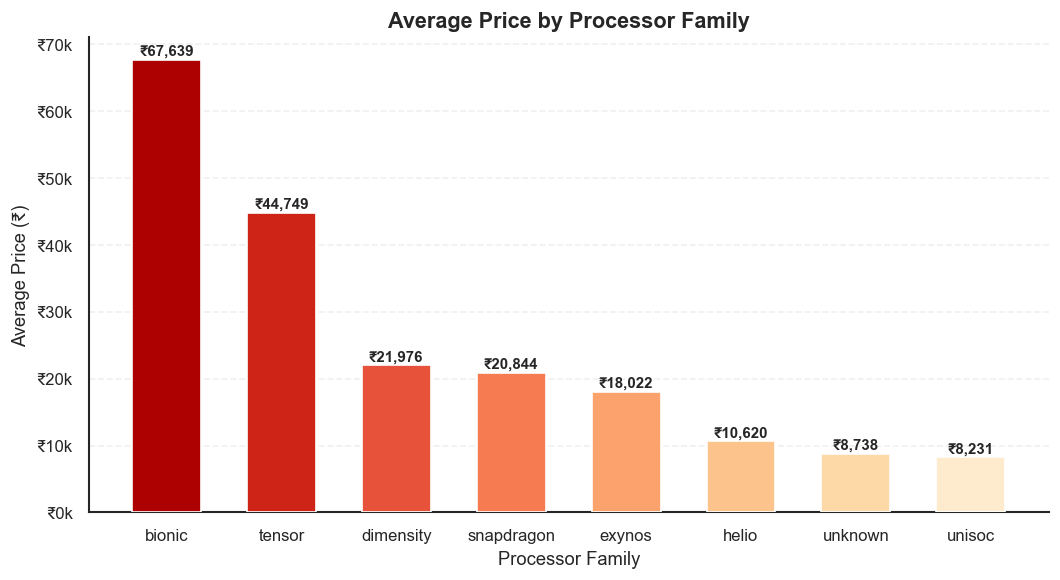

Device count per processor family:
proc_family
helio         167
snapdragon    127
dimensity     109
unisoc         61
exynos         28
unknown         9
tensor          8
bionic          5
Name: count, dtype: int64


In [102]:
fig, ax = plt.subplots(figsize=(9, 5))

proc_price = df.groupby('proc_family')['Price'].mean().round(0).sort_values(ascending=False)
colors     = sns.color_palette('OrRd_r', len(proc_price))

bars = ax.bar(proc_price.index, proc_price.values,
              color=colors, edgecolor='white', width=0.6, zorder=3)

for bar, val in zip(bars, proc_price.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'₹{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Price by Processor Family', fontsize=13, fontweight='bold')
ax.set_xlabel('Processor Family')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

print("Device count per processor family:")
print(df['proc_family'].value_counts())

* Price clearly changes based on processor family. Bionic (~ ₹67,639) and Tensor (~ ₹44,749) sit at the top, which shows these are premium processors used in high-end phones.
* Dimensity (~ ₹21,976) and Snapdragon (~₹20,844) stay in the mid range. These processors appear in many devices and offer a balance between performance and price.
* Exynos (~ ₹18,022) sits slightly lower, while Helio (~ ₹10,620) and Unisoc (~ ₹8,231) fall in the budget range.
* Device count explains this pattern clearly. Helio (167), Snapdragon (127), and Dimensity (109) have the highest counts, which shows most phones use mid and budget processors. On the other hand, Bionic (5) and Tensor (8) have very few devices but very high prices, which pushes their average up.
* So overall, processor type strongly affects price. Premium processors are associated with a high price, while budget processors keep prices low.

#### E. 5G vs Price

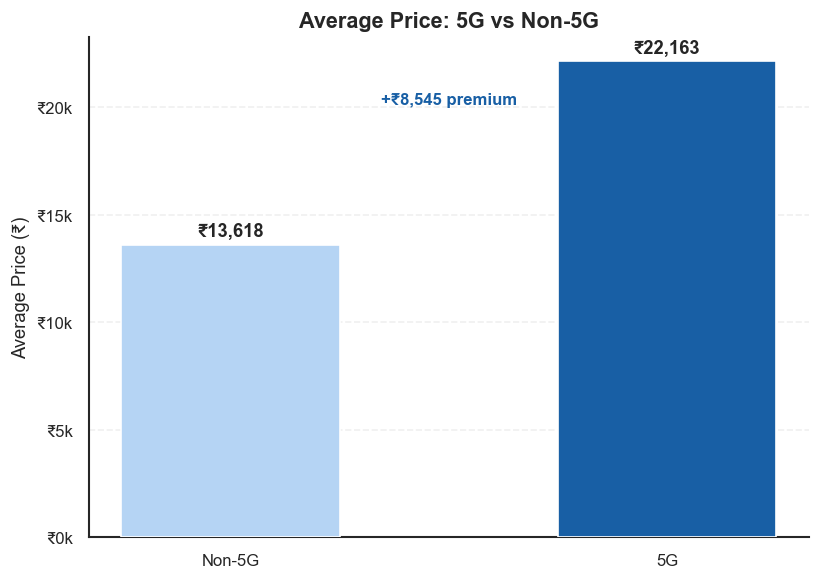

In [103]:
fig, ax = plt.subplots(figsize=(7, 5))
g5_price = df.groupby('is_5g')['Price'].mean().round(0)
labels   = ['Non-5G', '5G']
colors   = ['#B5D4F4', '#185FA5']
bars = ax.bar(labels, g5_price.values, color=colors, edgecolor='white', width=0.5, zorder=3)
for bar, val in zip(bars, g5_price.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'₹{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
diff = int(g5_price[1] - g5_price[0])
ax.annotate(f'+₹{diff:,} premium', xy=(1, g5_price[1]),
            xytext=(0.5, g5_price[1] - 2000),
            fontsize=10, color='#185FA5', fontweight='bold', ha='center')
ax.set_title('Average Price: 5G vs Non-5G', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

* 5G phones clearly cost more than non-5G phones. Non-5G phones average around ₹13,618, while 5G phones go up to around ₹22,163. This shows a price difference of about ₹8,500.
* This happens because 5G support is a newer feature and usually comes with better processors and overall higher specifications, which increases the price.
* So overall, 5G is not just a network feature; it also reflects a higher device segment, and phones with 5G are generally more expensive.

#### F. Camera Score vs Price

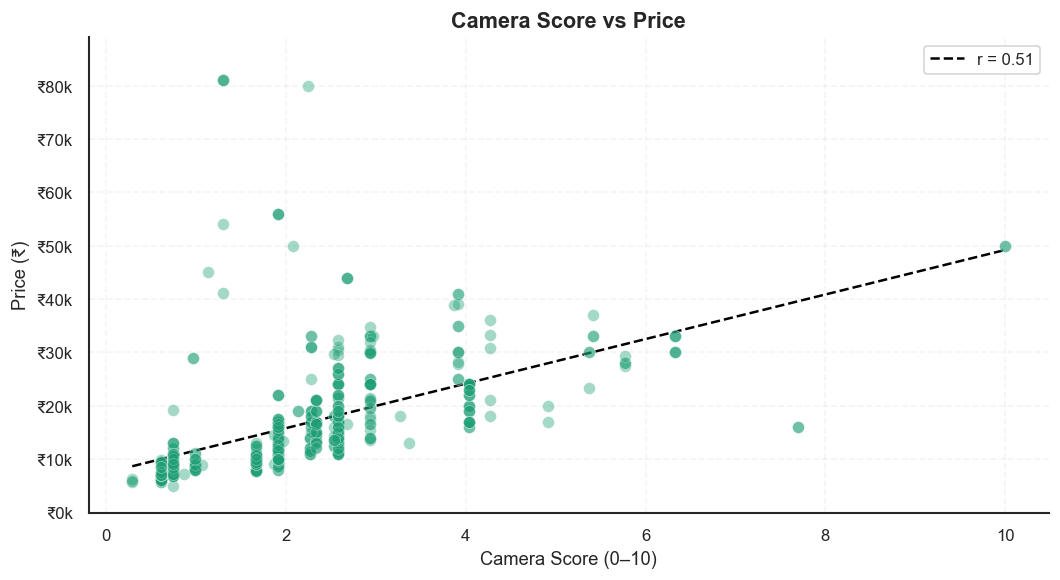

In [104]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['camera_score'], df['Price'], alpha=0.4, color='#1D9E75',
           edgecolors='white', linewidth=0.3, s=50, zorder=3)

m, b   = np.polyfit(df['camera_score'], df['Price'], 1)
x_line = np.linspace(df['camera_score'].min(), df['camera_score'].max(), 100)
corr   = df['camera_score'].corr(df['Price'])

ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5,
        linestyle='--', label=f'r = {corr:.2f}')

ax.set_title('Camera Score vs Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Camera Score (0–10)')
ax.set_ylabel('Price (₹)')
ax.set_ylim(0, df['Price'].max() * 1.1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.2, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

* Price increases as camera score increases, which shows a positive relationship between camera quality and price. The correlation is around 0.51, which means the relationship is moderate, not very strong.
* This means better camera quality generally leads to a higher price, but it is not the only factor. There are many phones with similar camera scores but different prices, which shows that other features like brand, processor, and RAM also affect price.
* Most phones are clustered between camera scores 1 to 4 and price ranges of ₹8K to ₹25K, which shows the majority of devices fall in the budget and mid-range.
* There are some high-priced phones even at lower camera scores, which clearly shows camera alone does not decide the price. At the same time, very high camera scores (above 6) mostly appear in higher-priced phones.
* So overall, camera quality does impact price, but it works along with other features, not alone.

#### G. Battery vs Price

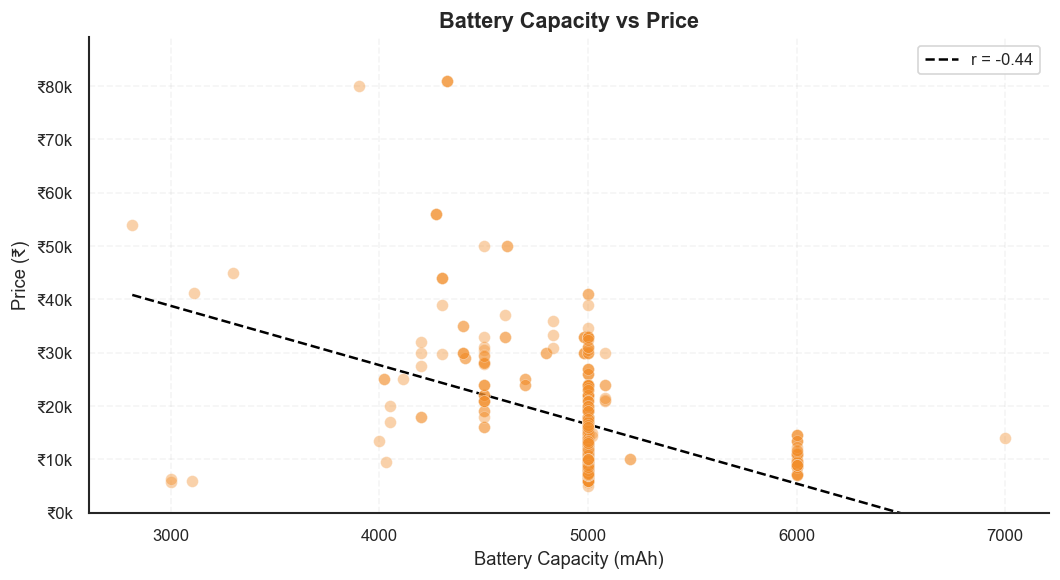

In [105]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['Battery'], df['Price'], alpha=0.4, color='#F28E2B',
           edgecolors='white', linewidth=0.3, s=50, zorder=3)

m, b   = np.polyfit(df['Battery'], df['Price'], 1)
x_line = np.linspace(df['Battery'].min(), df['Battery'].max(), 100)
corr   = df['Battery'].corr(df['Price'])

ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5,
        linestyle='--', label=f'r = {corr:.2f}')

ax.set_title('Battery Capacity vs Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Battery Capacity (mAh)')
ax.set_ylabel('Price (₹)')
ax.set_ylim(0, df['Price'].max() * 1.1)   # ← fixes line going below ₹0
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.2, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

* Battery shows a negative relationship with price (r ≈ -0.44), which means as battery capacity increases, price tends to decrease.
* This may look surprising, but it makes sense when you look at the market. Most budget and mid-range phones come with large batteries (5000 to 6000 mAh), while many premium phones focus more on design, performance, and camera instead of just increasing battery size.
* You can see most phones are clustered around 5000 mAh, especially in the ₹10K to ₹25K range. Higher battery values like 6000 to 7000 mAh mostly appear in lower to mid-priced phones.
* There are also some expensive phones with average battery (around 4000 to 4500 mAh), which shows battery is not a strong factor in deciding price.
* So overall, battery does not drive price upward. Instead, a higher battery is more common in budget phones, which creates this negative relationship.

#### H. Mobile Height vs Price

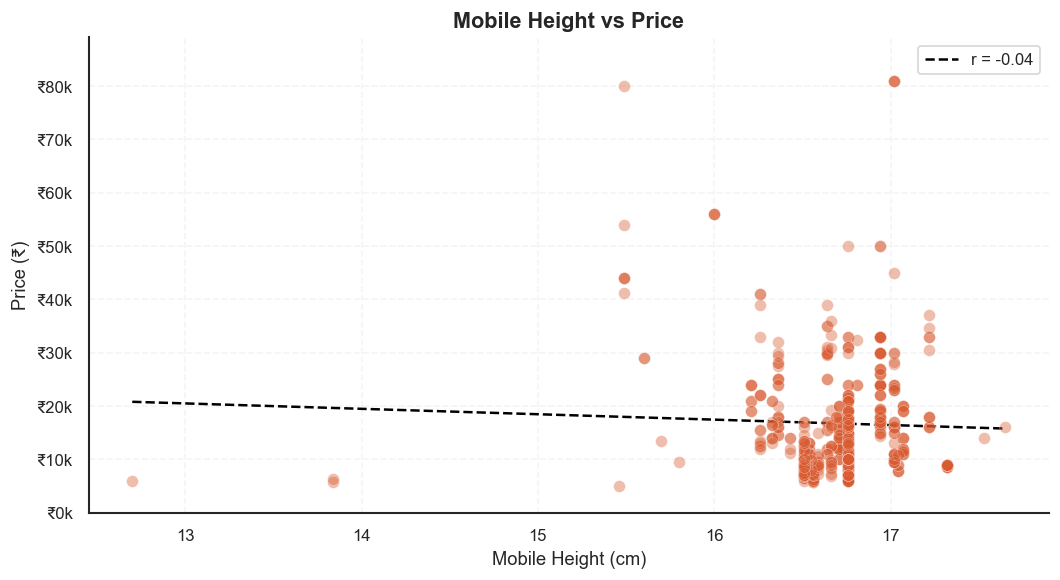

In [106]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['Mobile Height'], df['Price'], alpha=0.4, color='#D85A30',
           edgecolors='white', linewidth=0.3, s=50, zorder=3)

m, b   = np.polyfit(df['Mobile Height'], df['Price'], 1)
x_line = np.linspace(df['Mobile Height'].min(), df['Mobile Height'].max(), 100)
corr   = df['Mobile Height'].corr(df['Price'])

ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5,
        linestyle='--', label=f'r = {corr:.2f}')

ax.set_title('Mobile Height vs Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Mobile Height (cm)')
ax.set_ylabel('Price (₹)')
ax.set_ylim(0, df['Price'].max() * 1.1)   # ← consistent floor at ₹0
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.2, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

* There is almost no relationship between mobile height and price (r ≈ 0.04). This means phone size does not affect pricing in any meaningful way.
* Most devices are tightly clustered between 16 to 17 cm, and within this range prices vary widely from low to high. This shows phones of similar size can belong to completely different price segments.
* A few smaller or slightly larger devices exist, but they do not follow any clear pricing pattern.
* So overall, mobile height does not influence price. It stays mostly standard across devices, and brands do not use size as a factor to increase or decrease price.

---
### 7. Multivariate Analysis

#### A. Correlation Heatmap

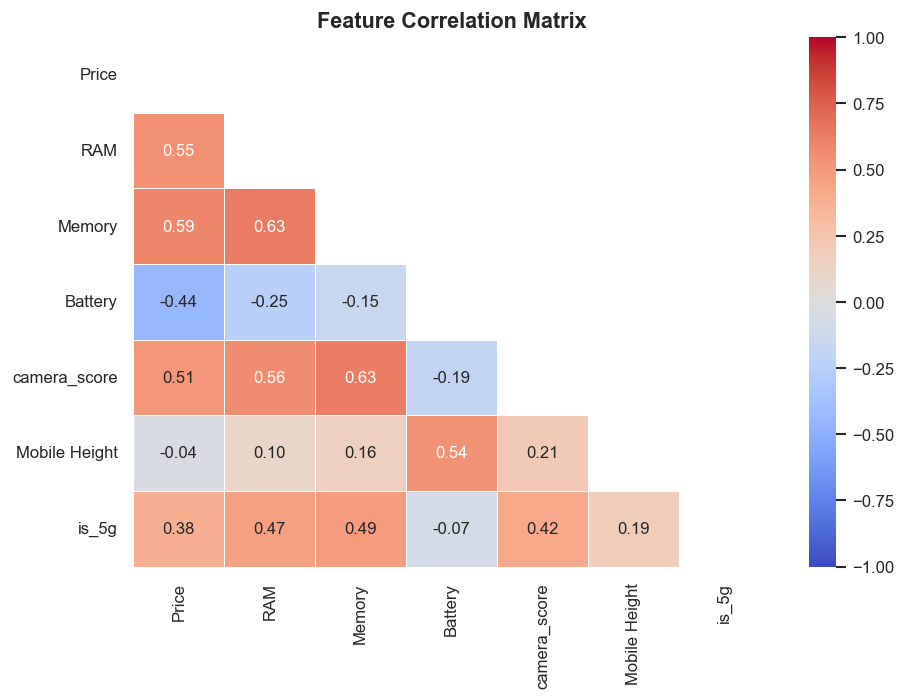

In [107]:
corr_matrix = df[['Price', 'RAM', 'Memory', 'Battery', 'camera_score', 'Mobile Height', 'is_5g']].corr()

plt.figure(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, annot_kws={'size': 10}, mask=mask,
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Price shows the strongest positive relationship with Memory (0.59), RAM (0.55), and Camera Score (0.51).
* This means these three features are the main drivers of price, as they increase, price also increases.
* 5G also shows a positive relationship with price (0.38), which confirms that 5G phones are generally more expensive.
* Battery shows a negative relationship with price (-0.44), which again confirms that a higher battery is more common in budget phones, not premium ones.
* Mobile Height shows almost no relationship with price (-0.04), which means size does not affect pricing.
* RAM, Memory, and Camera Score are also strongly related to each other (around 0.5–0.6), which shows that better devices usually come with better specs together, not separately.
* So overall, price mainly depends on performance-related features (RAM, Memory, Camera), while battery and size do not play a major role.

#### B. RAM × Processor Family × Price

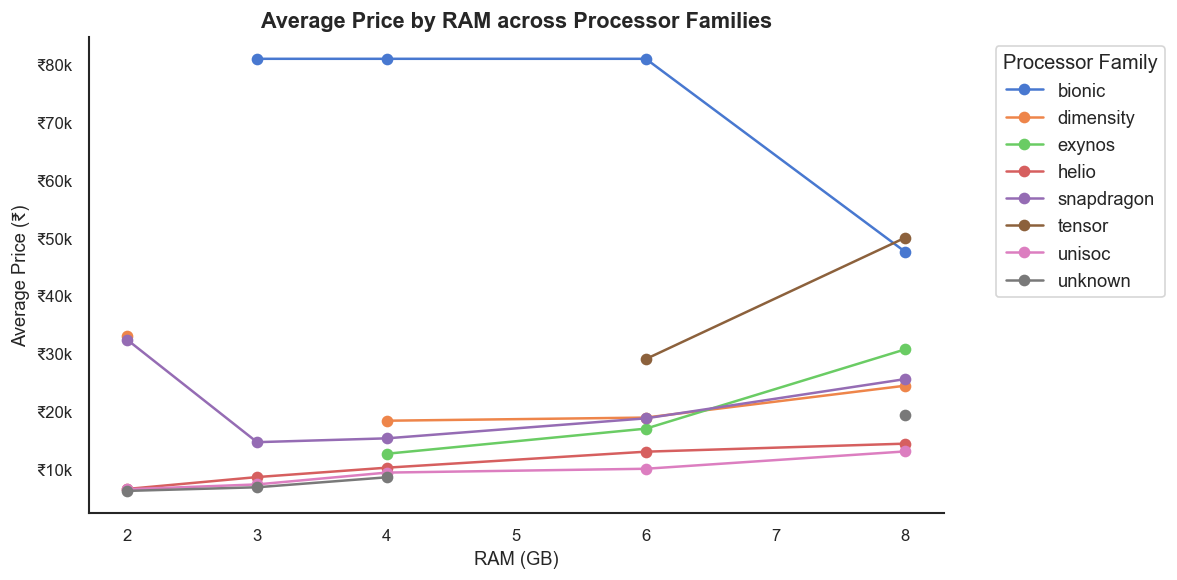

In [108]:
fig, ax = plt.subplots(figsize=(10, 5))

pivot = df.pivot_table(values='Price', index='RAM', columns='proc_family', aggfunc='mean')
pivot.plot(marker='o', ax=ax, linewidth=1.5)

ax.set_title('Average Price by RAM across Processor Families', fontsize=13, fontweight='bold')
ax.set_xlabel('RAM (GB)')
ax.set_ylabel('Average Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x/1000)}k'))
plt.legend(title='Processor Family', bbox_to_anchor=(1.05, 1))
sns.despine()
plt.tight_layout()
plt.show()

* Price increases with RAM across all processor families, but the level of increase depends strongly on the processor type.
* Bionic and Tensor stay at the top across RAM levels, which shows these processors always belong to premium phones, even when RAM changes.
* Snapdragon, Dimensity, and Exynos sit in the mid-range. As RAM increases, its price also increases steadily, which shows a clear balance between performance and cost.
* Helio and Unisoc stay in the lower range even at higher RAM, which shows that processor type can limit price even if RAM is high.
* This clearly shows RAM alone does not decide price. The same RAM (like 6GB or 8GB) can have very different prices depending on the processor family.
* So overall, price depends on a combination of RAM and processor, where the processor plays a major role in defining whether a phone is budget, mid-range, or premium.

#### C. Feature Averages by Price Tier

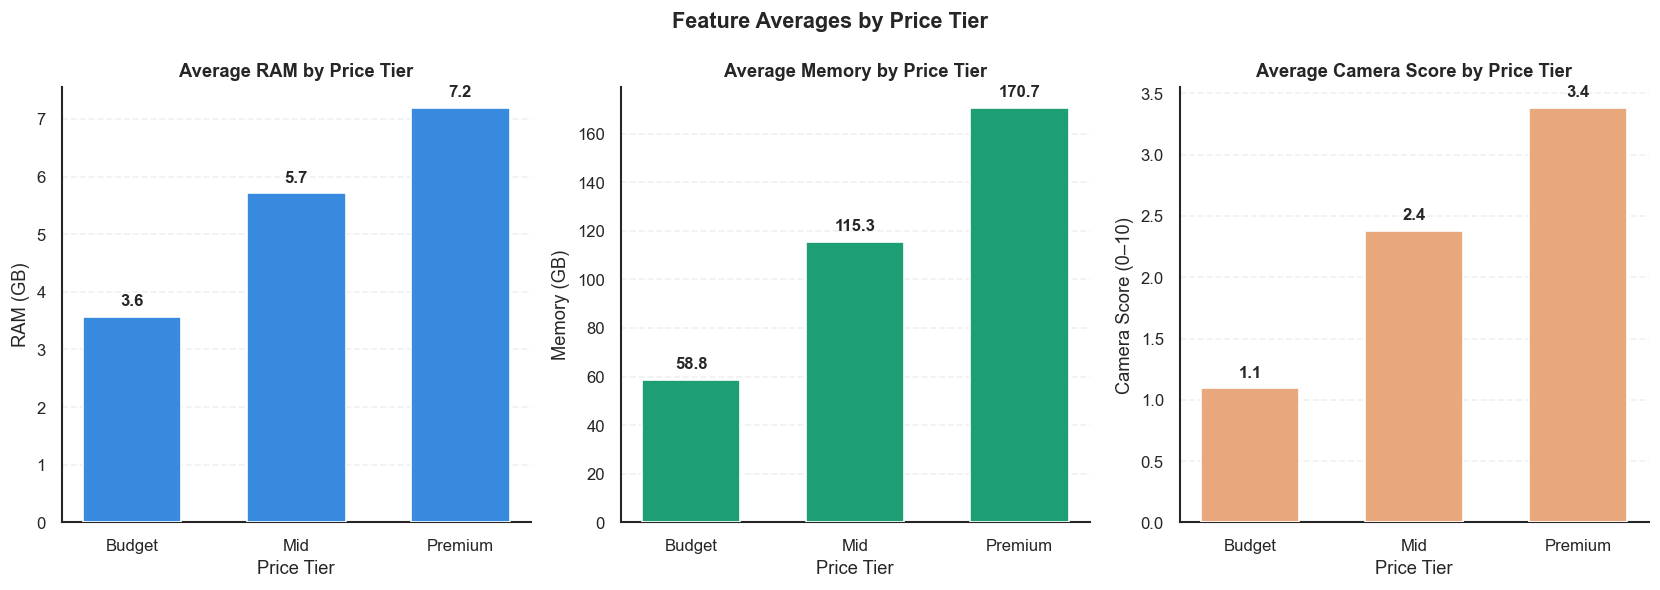

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

features = ['RAM', 'Memory', 'camera_score']
colors   = ['#378ADD', '#1D9E75', '#E8A87C']
titles   = ['Average RAM by Price Tier', 'Average Memory by Price Tier', 'Average Camera Score by Price Tier']
ylabels  = ['RAM (GB)', 'Memory (GB)', 'Camera Score (0–10)']
order    = ['Budget', 'Mid', 'Premium']

for ax, feat, color, title, ylabel in zip(axes, features, colors, titles, ylabels):
    means = df.groupby('price_tier', observed=True)[feat].mean().reindex(order)
    bars  = ax.bar(order, means.values, color=color, edgecolor='white', width=0.6, zorder=3)

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + means.max() * 0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Price Tier')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    sns.despine()

plt.suptitle('Feature Averages by Price Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* As we move from Budget to Mid to Premium, all key features show a clear increase.
* RAM increased from 3.6GB in budget devices to 5.7GB in mid-range and 7.2GB in premium devices. This shows that higher-priced phones support better multitasking and overall performance.
* Memory also increases strongly, from 58.8GB to 115.3GB and then to 170.7GB. This means higher price segments offer more storage capacity.
* Camera score improves from 1.1 in budget devices to 2.4 in mid-range and 3.4 in premium devices, which reflects better camera quality in higher segments.
* This pattern shows that the price is not random. Higher-priced devices consistently offer better performance, more storage, and improved camera quality.
* Overall, price tiers clearly separate devices based on overall quality, not just a single feature.

#### D. 5G Adoption by Brand

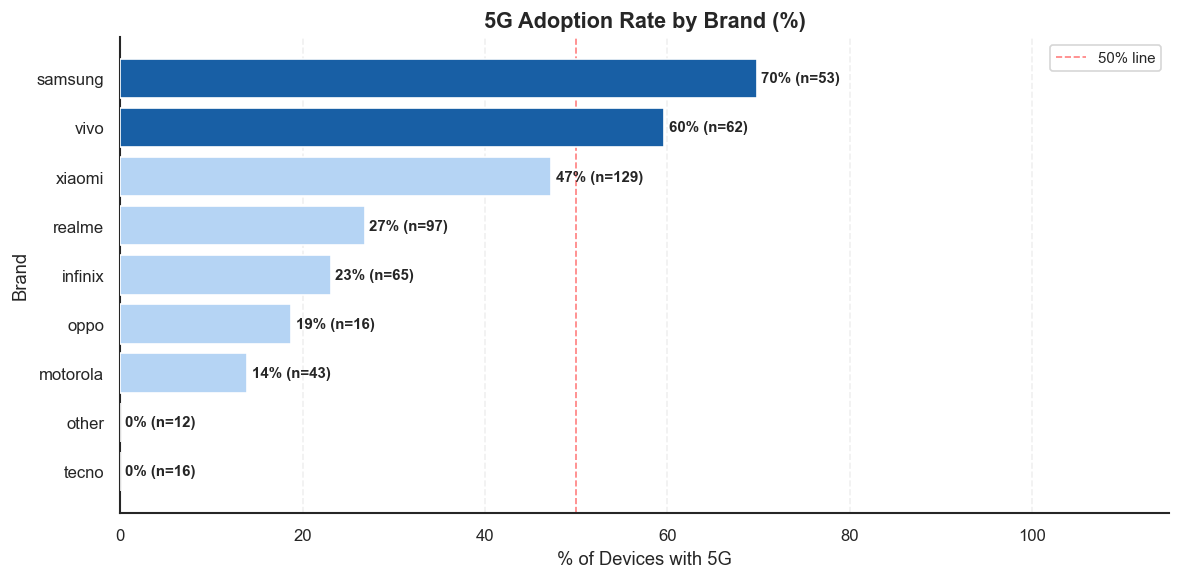

In [110]:
fig, ax = plt.subplots(figsize=(10, 5))

brand_counts = df['brand'].value_counts()

# Keep only reliable brands
valid_brands = brand_counts[brand_counts >= 10].index

brand_5g = (
    df[df['brand'].isin(valid_brands)]
    .groupby('brand')['is_5g']
    .mean()
    .sort_values(ascending=False) * 100
)

# Colors (highlight >= 50%)
colors = ['#185FA5' if v >= 50 else '#B5D4F4' for v in brand_5g.values]

bars = ax.barh(brand_5g.index, brand_5g.values, color=colors, edgecolor='white', zorder=3)

for bar, val, brand in zip(bars, brand_5g.values, brand_5g.index):
    count = brand_counts[brand]
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}% (n={count})',
            va='center', fontsize=9, fontweight='bold')

ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% line')
ax.set_title('5G Adoption Rate by Brand (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% of Devices with 5G')
ax.set_ylabel('Brand')
ax.set_xlim(0, 115)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

sns.despine()
plt.tight_layout()
plt.show()

* We check how 5G support changes across price segments.
* Samsung and Vivo lead in 5G adoption. These brands show a strong shift toward newer technology.
* Xiaomi stays close to the 50% mark. This shows a balanced mix of 4G and 5G devices.
* Realme and Infinix stay below 30%. These brands focus more on budget segments where 5G adoption is lower.
* Oppo and Motorola also show low 5G adoption, which suggests a slower shift toward 5G in the current lineup.
* Tecno and other smaller brands show 0% 5G adoption in this dataset. This means the selected models for these brands are all non-5G, not that these brands do not offer 5G devices overall.
* Overall pattern shows that higher 5G adoption is more common in brands that target mid to premium segments.

---

### 8. Business Insights:-

* Most devices fall in the mid-price range. This shows that customers prefer balanced phones with good features at a reasonable price. Premium devices exist, but they are fewer.
* Price increases clearly with RAM. Devices with 6GB and 8GB RAM have a much higher average price. This shows that RAM is one of the main drivers of pricing.
* Price increases steadily from 64GB to 128GB and 256GB. 128GB is the most common configuration, which shows it is the standard expectation in the market.
* The processor family directly impacts the price. Premium processors like Bionic and Tensor are used in high-end devices, while Helio and Unisoc are used in budget devices. This shows clear segmentation based on performance.
* Some brands consistently price higher, even with similar specs. This shows that brand value and positioning affect pricing beyond hardware features.
* 5G devices have a higher average price compared to non-5G devices. This shows that 5G is still treated as a premium feature in the market.
* Higher camera score generally aligns with a higher price, but the relationship is not strong. Devices with similar camera scores show different prices. This means the camera is important, but not the only deciding factor.
* Battery capacity shows a weak correlation with price. Many budget devices offer large batteries. This shows battery is a standard feature, not a premium differentiator.
* No single feature fully explains price. Price depends on a combination of RAM, processor, storage, brand, and connectivity.
* Invalid entries, like feature phones and incorrect values, distort insights. Cleaning such data improves reliability and makes patterns more meaningful.

---

### 9. Business Recommendations:-

* Companies should target the mid-price range with balanced features. This segment has the highest demand and offers better volume potential.
* Increasing RAM and storage is a strong way to justify a higher price. These features are clearly linked to customer perception of value.
* The processor selection should match the target price segment. Premium devices need high-end processors to deliver strong performance and justify higher pricing, while budget devices should focus on cost efficiency by using mid-range or lower-end processors that still provide acceptable performance without increasing the price too much.
* 5G can be used as a premium feature in marketing and pricing. Adding 5G support can increase perceived value.
* The camera alone does not define price. Front camera shows a stronger impact on price compared to rear camera, which suggests that brands focus more on selfie and video features in higher-priced devices. However, the camera should still be combined with performance and brand positioning to create stronger products.
* Brand value allows higher pricing even with similar specs. Companies should invest in brand perception and trust.
* Battery is expected, not a differentiator. Focus on efficiency instead of just increasing capacity.
* Wrong or inconsistent data leads to incorrect insights. Proper validation and cleaning are necessary before analysis.
* Customers respond better to overall value (RAM + storage + processor + 5G) rather than one strong feature.
* Product decisions should be based on real usage patterns and feature impact instead of assumptions.